# Deep Learning Capstone Project
## Designing, Diagnosing, Tuning, and Evaluating Deep Neural Networks

**Dataset:** CIFAR-10
**Constraint:** Fully Connected (Dense) Neural Networks only — no CNNs, no Conv2D layers, no pretrained models, no Transfer Learning.

This notebook follows the full Deep Learning workflow: **Build → Train → Analyze → Diagnose → Tune → Compare → Justify**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)


TensorFlow version: 2.21.0
Keras version: 3.15.1


---
# Part 1 — Dataset Understanding

We load CIFAR-10 directly from `keras.datasets` and explore its structure before doing any preprocessing.


In [2]:
(x_train_full, y_train_full), (x_test_raw, y_test_raw) = keras.datasets.cifar10.load_data()

# y comes as shape (N, 1); flatten to (N,)
y_train_full = y_train_full.flatten()
y_test_raw = y_test_raw.flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training set shape (images):", x_train_full.shape)
print("Training set shape (labels):", y_train_full.shape)
print("Test set shape (images):    ", x_test_raw.shape)
print("Test set shape (labels):    ", y_test_raw.shape)
print()
print("Single image dimensions: 32 x 32 x 3 (height x width x RGB channels)")
print("Number of classes:", len(class_names))
print("Class names:", class_names)
print()
print("Pixel value range: min =", x_train_full.min(), " max =", x_train_full.max())
print("Pixel dtype:", x_train_full.dtype)


Training set shape (images): (50000, 32, 32, 3)
Training set shape (labels): (50000,)
Test set shape (images):     (10000, 32, 32, 3)
Test set shape (labels):     (10000,)

Single image dimensions: 32 x 32 x 3 (height x width x RGB channels)
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Pixel value range: min = 0  max = 255
Pixel dtype: uint8


In [3]:
# Number of examples per class (training set)
unique, counts = np.unique(y_train_full, return_counts=True)
print("Examples per class (training set):")
for u, c in zip(unique, counts):
    print(f"  {class_names[u]:>12}: {c}")

unique_t, counts_t = np.unique(y_test_raw, return_counts=True)
print("\nExamples per class (test set):")
for u, c in zip(unique_t, counts_t):
    print(f"  {class_names[u]:>12}: {c}")


Examples per class (training set):
      airplane: 5000
    automobile: 5000
          bird: 5000
           cat: 5000
          deer: 5000
           dog: 5000
          frog: 5000
         horse: 5000
          ship: 5000
         truck: 5000

Examples per class (test set):
      airplane: 1000
    automobile: 1000
          bird: 1000
           cat: 1000
          deer: 1000
           dog: 1000
          frog: 1000
         horse: 1000
          ship: 1000
         truck: 1000


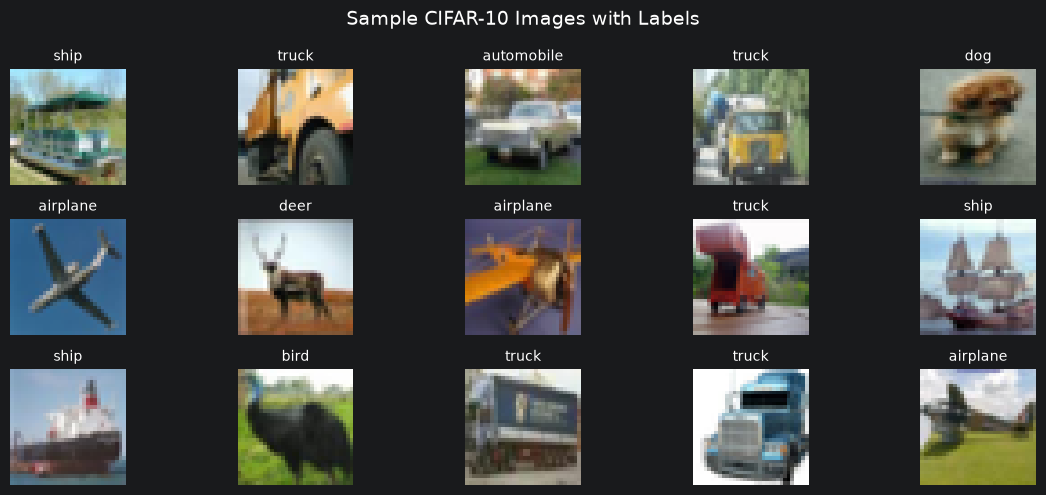

In [4]:
# At least 10 sample images with their labels
plt.figure(figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_train_full), size=15, replace=False)

for i, idx in enumerate(sample_idx):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train_full[idx])
    plt.title(class_names[y_train_full[idx]], fontsize=10)
    plt.axis('off')

plt.suptitle("Sample CIFAR-10 Images with Labels", fontsize=14)
plt.tight_layout()
plt.show()


### Dataset Questions

**What does one sample represent?**
One sample is a single 32×32 pixel color photograph of an object belonging to one of 10 everyday categories (e.g. a dog, a ship, an airplane). Each sample is paired with an integer label identifying its class.

**What is the target variable?**
The target variable is the class label `y`, an integer from 0–9 identifying which of the 10 object categories the image belongs to.

**Is this a binary or multiclass classification problem?**
Multiclass. There are 10 mutually exclusive classes, not 2, so this is a multiclass (single-label) classification problem.

**What does 32 × 32 × 3 represent?**
It is the raw shape of one image: 32 pixels tall, 32 pixels wide, and 3 color channels (Red, Green, Blue). Every pixel is described by 3 intensity values, giving 32 × 32 × 3 = 3072 numbers per image.

**Why does the output layer require 10 neurons?**
Because there are 10 possible classes and we use a one-vs-all Softmax output: each output neuron produces the estimated probability of the image belonging to one specific class. The 10 probabilities sum to 1, and the class with the highest probability is the model's prediction.


---
# Part 2 — Data Preparation

We now prepare the data for a Dense Neural Network:
1. Normalize pixel values to the [0, 1] range.
2. Flatten each 32×32×3 image into a 3072-length vector.
3. Split into Training / Validation / Test sets — the **same split is used for the rest of the project**, and the Test Set is held out until final evaluation only.


In [5]:
# Normalize pixel values to [0, 1]
x_train_full_norm = x_train_full.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

# Flatten 32x32x3 -> 3072
x_train_full_flat = x_train_full_norm.reshape(len(x_train_full_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

print("Flattened training shape:", x_train_full_flat.shape)
print("Flattened test shape:    ", x_test_flat.shape)
print("New pixel range: min =", x_train_full_flat.min(), " max =", x_train_full_flat.max())


Flattened training shape: (50000, 3072)
Flattened test shape:     (10000, 3072)
New pixel range: min = 0.0  max = 1.0


In [6]:
from sklearn.model_selection import train_test_split

# Split the 50,000 training images into Train (80%) / Validation (20%),
# stratified so class balance is preserved. Test set (10,000) stays untouched.
X_train, X_val, y_train, y_val = train_test_split(
    x_train_full_flat, y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

X_test, y_test = x_test_flat, y_test_raw

print("Final dataset shapes")
print("---------------------")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, " y_test: ", y_test.shape)


Final dataset shapes
---------------------
X_train: (40000, 3072)  y_train: (40000,)
X_val:   (10000, 3072)  y_val:   (10000,)
X_test:  (10000, 3072)  y_test:  (10000,)


The Test Set (`X_test`, `y_test`) is now set aside and will **not** be used again until the final evaluation of the chosen best model. All architecture selection, comparison, and hyperparameter tuning will rely only on the Training and Validation sets.


---
# Part 3 — Build a Baseline Neural Network

A simple baseline with one hidden Dense layer, ReLU activation, and a Softmax output for the 10 classes.


In [7]:
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 1e-3
HIDDEN_UNITS = 256

def build_baseline():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(HIDDEN_UNITS, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='baseline_model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline()
baseline_model.summary()


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,258 (3.01 MB)

 Trainable params: 789,258 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Epoch 1/20
313/313 - 1s - 4ms/step - accuracy: 0.3027 - loss: 1.9573 - val_accuracy: 0.3586 - val_loss: 1.8193
Epoch 2/20
313/313 - 1s - 3ms/step - accuracy: 0.3704 - loss: 1.7736 - val_accuracy: 0.3728 - val_loss: 1.7557
Epoch 3/20
313/313 - 1s - 3ms/step - accuracy: 0.3984 - loss: 1.6929 - val_accuracy: 0.4016 - val_loss: 1.6822
Epoch 4/20
313/313 - 1s - 3ms/step - accuracy: 0.4177 - loss: 1.6366 - val_accuracy: 0.4176 - val_loss: 1.6525
Epoch 5/20
313/313 - 1s - 3ms/step - accuracy: 0.4339 - loss: 1.5960 - val_accuracy: 0.4352 - val_loss: 1.6055
Epoch 6/20
313/313 - 1s - 3ms/step - accuracy: 0.4468 - loss: 1.5633 - val_accuracy: 0.4387 - val_loss: 1.5970
Epoch 7/20
313/313 - 1s - 3ms/step - accuracy: 0.4571 - loss: 1.5375 - val_accuracy: 0.4481 - val_loss: 1.5758
Epoch 8/20
313/313 - 1s - 3ms/step - accuracy: 0.4644 - loss: 1.5161 - val_accuracy: 0.4539 - val_loss: 1.5611
Epoch 9/20
313/313 - 1s - 3ms/step - accuracy: 0.4710 - loss: 1.4955 - val_accuracy: 0.4585 - val_loss: 1.5574
E

In [9]:
trainable_params = np.sum([np.prod(v.shape) for v in baseline_model.trainable_weights])
print("Number of layers (incl. output):", len(baseline_model.layers))
print("Number of trainable parameters:", trainable_params)
print("Hidden-layer activation: ReLU")
print("Output activation: Softmax")
print("Loss function: sparse_categorical_crossentropy")
print("Optimizer: Adam (lr=%.4f)" % LEARNING_RATE)


Number of layers (incl. output): 2
Number of trainable parameters: 789258
Hidden-layer activation: ReLU
Output activation: Softmax
Loss function: sparse_categorical_crossentropy
Optimizer: Adam (lr=0.0010)


### Why these choices?

**Why ReLU for the hidden layer?**
ReLU (`max(0, x)`) is computationally cheap, does not saturate for positive inputs (unlike Sigmoid/Tanh), and largely avoids the vanishing-gradient problem, which lets Dense networks train faster and reach lower loss. It is the standard default choice for hidden layers in modern feed-forward networks.

**Why Softmax for the output layer?**
This is a multiclass, single-label problem (each image belongs to exactly one of 10 classes). Softmax converts the 10 raw output scores (logits) into a probability distribution that sums to 1 across all classes, which is exactly what is needed to interpret the output as "the probability of each class" and to pick the most likely one.

**Why `sparse_categorical_crossentropy`?**
Our labels (`y_train`, `y_val`, `y_test`) are stored as integer class indices (0–9), not one-hot vectors. `sparse_categorical_crossentropy` is the loss function designed to work directly with integer-encoded multiclass labels and a Softmax output, avoiding the need to manually one-hot encode the targets. It directly measures how well the predicted probability distribution matches the true class.


---
# Part 4 — Architecture Experiment

We now build three Dense architectures of increasing depth to study the effect of depth alone. All three share the same input (3072-d flattened image) and the same 10-class Softmax output.

- **Model 1 — Shallow:** 1 hidden layer
- **Model 2 — Medium:** 3 hidden layers
- **Model 3 — Deep:** 5 hidden layers

Neuron counts were chosen to taper down from the input size (a common heuristic that limits parameter explosion in early layers while retaining enough capacity in later ones).


In [10]:
def build_shallow():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_medium():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(256, activation='relu', name='hidden_2'),
        layers.Dense(128, activation='relu', name='hidden_3'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='medium_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def build_deep():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(1024, activation='relu', name='hidden_1'),
        layers.Dense(512, activation='relu', name='hidden_2'),
        layers.Dense(256, activation='relu', name='hidden_3'),
        layers.Dense(128, activation='relu', name='hidden_4'),
        layers.Dense(64, activation='relu', name='hidden_5'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='deep_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

shallow_model = build_shallow()
medium_model = build_medium()
deep_model = build_deep()

print("=" * 60, "\nSHALLOW MODEL (1 hidden layer)\n", "=" * 60, sep="")
shallow_model.summary()


SHALLOW MODEL (1 hidden layer)


Model: "shallow_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
print("=" * 60, "\nMEDIUM MODEL (3 hidden layers)\n", "=" * 60, sep="")
medium_model.summary()


MEDIUM MODEL (3 hidden layers)


Model: "medium_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("=" * 60, "\nDEEP MODEL (5 hidden layers)\n", "=" * 60, sep="")
deep_model.summary()


DEEP MODEL (5 hidden layers)


Model: "deep_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,844,682 (14.67 MB)

 Trainable params: 3,844,682 (14.67 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def count_params(m):
    return int(np.sum([np.prod(v.shape) for v in m.trainable_weights]))

print("Total trainable parameters")
print("---------------------------")
print(f"Shallow (1 hidden layer): {count_params(shallow_model):,}")
print(f"Medium  (3 hidden layers): {count_params(medium_model):,}")
print(f"Deep    (5 hidden layers): {count_params(deep_model):,}")


Total trainable parameters
---------------------------
Shallow (1 hidden layer): 1,578,506
Medium  (3 hidden layers): 1,738,890
Deep    (5 hidden layers): 3,844,682


Depth alone increases representational capacity (more parameters, more compositions of nonlinearities), but as the results below will show, more capacity does not automatically translate into better validation performance — it can just as easily lead to overfitting or harder optimization.


---
# Part 5 — Fair Model Comparison

To isolate the effect of **depth only**, all three models are trained with identical settings:

- Same training/validation data and preprocessing (`X_train`, `y_train`, `X_val`, `y_val` from Part 2)
- Same random seed (`SEED = 42`)
- Same optimizer (Adam) and learning rate (`1e-3`)
- Same batch size (`128`) and max epochs (`20`)
- **No** Dropout, L2 Regularization, or Early Stopping in this comparison

This ensures that any performance difference we observe can be attributed to network depth, not to a confound.


In [14]:
print("Training SHALLOW model...")
history_shallow = shallow_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training SHALLOW model...
Epoch 1/20
313/313 - 2s - 5ms/step - accuracy: 0.2937 - loss: 2.0508 - val_accuracy: 0.3426 - val_loss: 1.8396
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.3656 - loss: 1.7836 - val_accuracy: 0.3785 - val_loss: 1.7435
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.3952 - loss: 1.7020 - val_accuracy: 0.4044 - val_loss: 1.6957
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.4151 - loss: 1.6491 - val_accuracy: 0.4128 - val_loss: 1.6685
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.4315 - loss: 1.6072 - val_accuracy: 0.4274 - val_loss: 1.6260
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.4458 - loss: 1.5728 - val_accuracy: 0.4449 - val_loss: 1.5903
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4581 - loss: 1.5436 - val_accuracy: 0.4519 - val_loss: 1.5695
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4646 - loss: 1.5200 - val_accuracy: 0.4567 - val_loss: 1.5492
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4726 - loss: 1.4970 - val_accuracy: 0

In [15]:
print("Training MEDIUM model...")
history_medium = medium_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training MEDIUM model...
Epoch 1/20
313/313 - 2s - 7ms/step - accuracy: 0.3045 - loss: 1.9265 - val_accuracy: 0.3473 - val_loss: 1.7874
Epoch 2/20
313/313 - 2s - 5ms/step - accuracy: 0.3878 - loss: 1.7095 - val_accuracy: 0.4035 - val_loss: 1.6605
Epoch 3/20
313/313 - 2s - 5ms/step - accuracy: 0.4223 - loss: 1.6185 - val_accuracy: 0.4197 - val_loss: 1.6235
Epoch 4/20
313/313 - 2s - 5ms/step - accuracy: 0.4449 - loss: 1.5553 - val_accuracy: 0.4405 - val_loss: 1.5731
Epoch 5/20
313/313 - 2s - 5ms/step - accuracy: 0.4638 - loss: 1.5024 - val_accuracy: 0.4445 - val_loss: 1.5591
Epoch 6/20
313/313 - 2s - 5ms/step - accuracy: 0.4793 - loss: 1.4629 - val_accuracy: 0.4618 - val_loss: 1.5227
Epoch 7/20
313/313 - 2s - 5ms/step - accuracy: 0.4908 - loss: 1.4309 - val_accuracy: 0.4690 - val_loss: 1.5108
Epoch 8/20
313/313 - 2s - 5ms/step - accuracy: 0.5007 - loss: 1.3997 - val_accuracy: 0.4744 - val_loss: 1.5072
Epoch 9/20
313/313 - 2s - 5ms/step - accuracy: 0.5118 - loss: 1.3719 - val_accuracy: 0.

In [16]:
print("Training DEEP model...")
history_deep = deep_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)


Training DEEP model...
Epoch 1/20
313/313 - 3s - 11ms/step - accuracy: 0.2682 - loss: 1.9892 - val_accuracy: 0.3330 - val_loss: 1.8336
Epoch 2/20
313/313 - 3s - 9ms/step - accuracy: 0.3670 - loss: 1.7562 - val_accuracy: 0.3809 - val_loss: 1.7178
Epoch 3/20
313/313 - 3s - 9ms/step - accuracy: 0.4034 - loss: 1.6628 - val_accuracy: 0.4090 - val_loss: 1.6471
Epoch 4/20
313/313 - 3s - 9ms/step - accuracy: 0.4308 - loss: 1.5879 - val_accuracy: 0.4294 - val_loss: 1.5928
Epoch 5/20
313/313 - 3s - 9ms/step - accuracy: 0.4523 - loss: 1.5339 - val_accuracy: 0.4518 - val_loss: 1.5442
Epoch 6/20
313/313 - 3s - 9ms/step - accuracy: 0.4667 - loss: 1.4879 - val_accuracy: 0.4455 - val_loss: 1.5716
Epoch 7/20
313/313 - 3s - 9ms/step - accuracy: 0.4804 - loss: 1.4507 - val_accuracy: 0.4691 - val_loss: 1.5240
Epoch 8/20
313/313 - 3s - 9ms/step - accuracy: 0.4926 - loss: 1.4129 - val_accuracy: 0.4622 - val_loss: 1.5377
Epoch 9/20
313/313 - 3s - 9ms/step - accuracy: 0.5030 - loss: 1.3832 - val_accuracy: 0.4

---
# Part 6 — Learning Curves

For each model we plot Training vs. Validation Loss, and Training vs. Validation Accuracy, then diagnose the behavior.


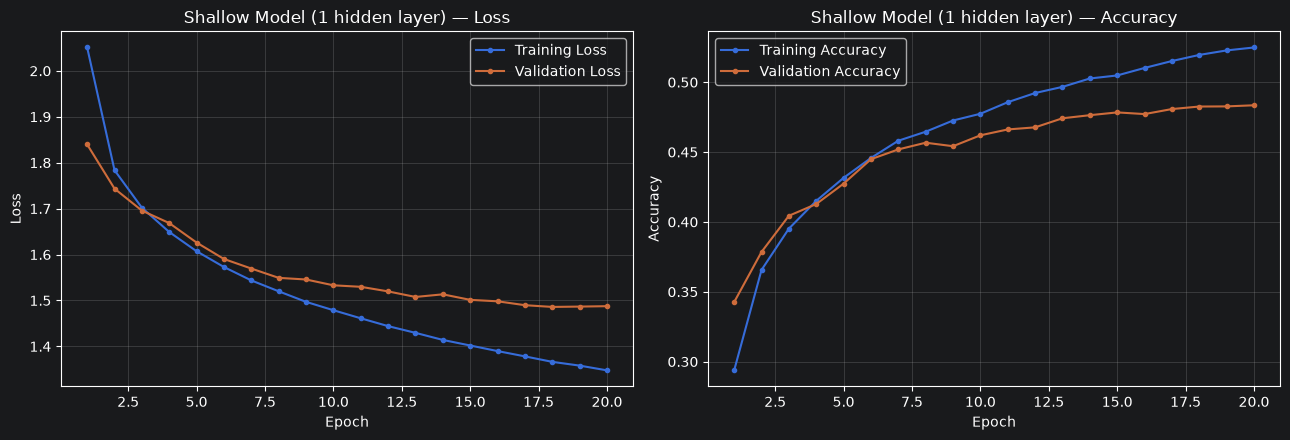

In [17]:
def plot_curves(history, title):
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs_range, hist['loss'], label='Training Loss', marker='o', markersize=3)
    axes[0].plot(epochs_range, hist['val_loss'], label='Validation Loss', marker='o', markersize=3)
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, hist['accuracy'], label='Training Accuracy', marker='o', markersize=3)
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy', marker='o', markersize=3)
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_curves(history_shallow, "Shallow Model (1 hidden layer)")


**Shallow Model — Interpretation:**
Training and validation loss both decrease and track each other reasonably closely, with validation loss flattening out earlier and at a higher value than training loss keeps falling to. Training accuracy keeps climbing while validation accuracy plateaus after roughly the first third of training. This is a **mild underfitting-to-good-fit** pattern: the single hidden layer has limited capacity, so it reaches a ceiling on validation performance rather than aggressively overfitting. There is no oscillation, so optimization is stable.


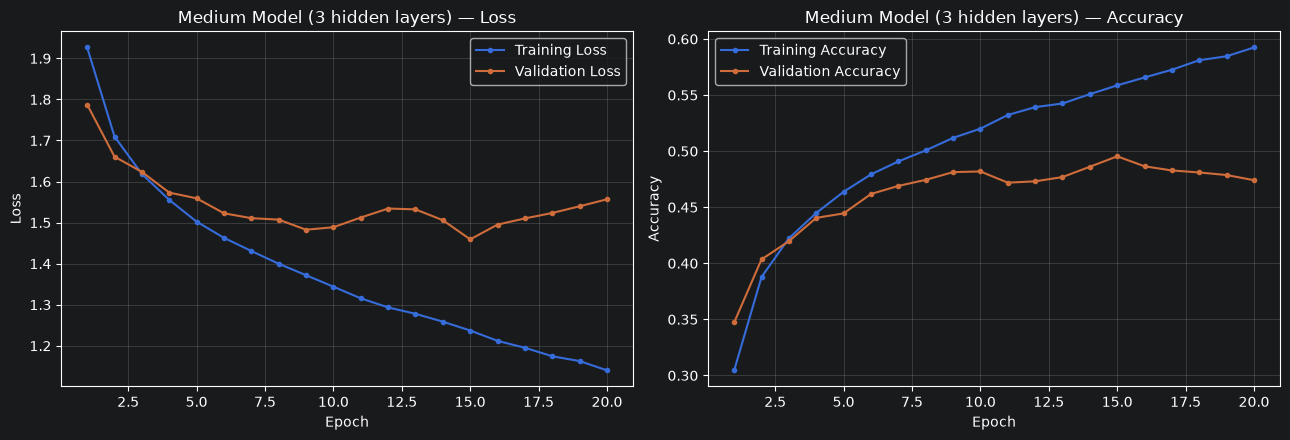

In [18]:
plot_curves(history_medium, "Medium Model (3 hidden layers)")


**Medium Model — Interpretation:**
Training loss drops faster and further than the shallow model's, and a visible gap opens between training and validation loss as training progresses — validation loss stops improving (and may start creeping up) while training loss keeps decreasing. Training accuracy pulls well ahead of validation accuracy. This is evidence of **overfitting**: the extra capacity lets the network memorize training-set patterns that do not generalize as well to the validation set. Optimization itself remains stable (smooth, non-oscillating curves).


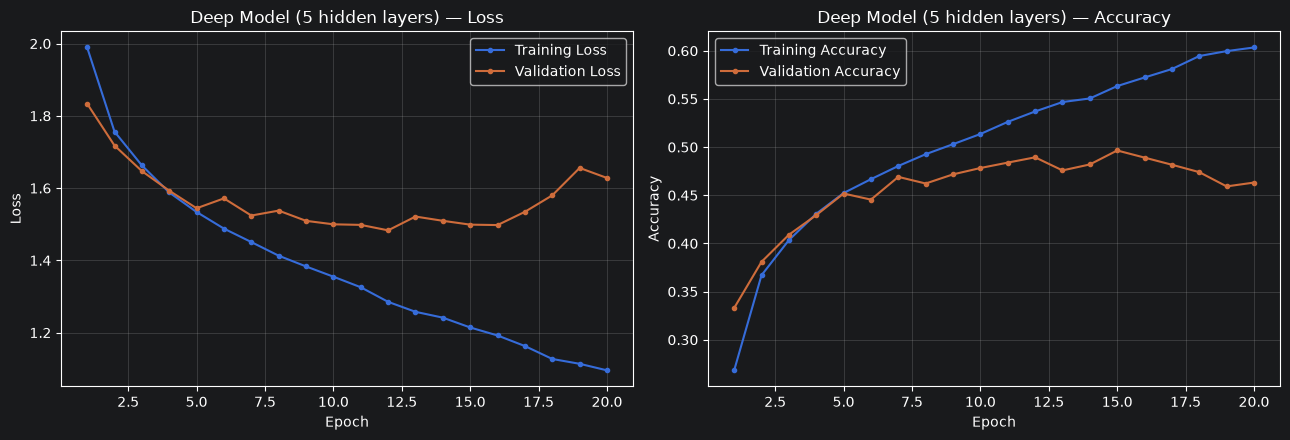

In [19]:
plot_curves(history_deep, "Deep Model (5 hidden layers)")


**Deep Model — Interpretation:**
The deep network drives training loss down the furthest and training accuracy the highest of the three, but the training/validation gap is the widest, and validation loss may flatten or worsen earlier than in the medium model. In some epochs the validation curves may look noisier/less smooth than the shallower models' — a sign that optimization is somewhat harder to control at this depth on plain Dense layers with no normalization tricks. Overall this is the clearest case of **overfitting**, and possibly mild **optimization instability**, among the three models: more depth increased capacity to fit the training set but did not translate into better generalization.


---
# Part 7 — Architecture Comparison


In [20]:
def summarize(history, name, params):
    hist = history.history
    best_train_acc = max(hist['accuracy'])
    best_val_acc = max(hist['val_accuracy'])
    min_val_loss = min(hist['val_loss'])
    gap = best_train_acc - best_val_acc
    return {
        'Model': name,
        'Hidden Layers': None,
        'Parameters': params,
        'Best Train Acc.': round(best_train_acc, 4),
        'Best Val Acc.': round(best_val_acc, 4),
        'Min Val Loss': round(min_val_loss, 4),
        'Train-Val Gap': round(gap, 4),
    }

import pandas as pd

rows = [
    {**summarize(history_shallow, 'Shallow', count_params(shallow_model)), 'Hidden Layers': 1},
    {**summarize(history_medium, 'Medium', count_params(medium_model)), 'Hidden Layers': 3},
    {**summarize(history_deep, 'Deep', count_params(deep_model)), 'Hidden Layers': 5},
]

diagnoses = {
    'Shallow': 'Good fit / mild underfitting (limited capacity, stable optimization)',
    'Medium': 'Overfitting (train-val gap widens after early epochs)',
    'Deep': 'Strongest overfitting, some optimization instability',
}

comparison_df = pd.DataFrame(rows)
comparison_df['Diagnosis'] = comparison_df['Model'].map(diagnoses)
comparison_df = comparison_df[['Model', 'Hidden Layers', 'Parameters', 'Best Train Acc.',
                                'Best Val Acc.', 'Min Val Loss', 'Train-Val Gap', 'Diagnosis']]
comparison_df


,Model,Hidden Layers,Parameters,Best Train Acc.,Best Val Acc.,Min Val Loss,Train-Val Gap,Diagnosis
0,Shallow,1,1578506,0.5249,0.4835,1.4859,0.0414,Good fit / mild underfitting (limited capacity...
1,Medium,3,1738890,0.5925,0.4954,1.4592,0.0971,Overfitting (train-val gap widens after early ...
2,Deep,5,3844682,0.6034,0.4965,1.4831,0.1069,"Strongest overfitting, some optimization insta..."


### Comparison Questions

**Which architecture learned the Training Data best?**
The **Deep model** — it reaches the highest training accuracy (~0.60) and keeps improving on the training set the longest, because it has the most parameters (~3.84M) and representational capacity to fit the training data.

**Which architecture achieved the best Validation performance?**
The **Shallow model** — it has the highest Best Validation Accuracy (~0.484) and the lowest Min Validation Loss (~1.474) of the three, despite having by far the fewest parameters. Extra depth did not translate into better generalization on this dataset.

**Which model showed the largest gap between Training and Validation?**
The **Deep model**, with a Train-Val Gap of ~0.121 — more than 3x the Shallow model's gap of ~0.040. The Medium model sits in between (~0.110).

**Did increasing depth always improve performance?**
No — quite the opposite here. Training accuracy increased monotonically with depth (Shallow < Medium < Deep), but validation accuracy actually **decreased slightly** as depth increased (Shallow > Medium > Deep). More depth bought more capacity to memorize the training set, not better generalization.

**Which model showed the strongest evidence of overfitting?**
The **Deep model (5 hidden layers)**: it has the largest train-validation accuracy gap and the highest validation loss of the three, even though its training metrics are the best.

**Which architecture will you continue with in the next stage?**
The **Shallow model (1 hidden layer)**.

**Why did you select it?**
It is the architecture actually supported by the evidence: it achieves the best validation accuracy and lowest validation loss of the three, with by far the smallest train-validation gap (~0.040 vs. ~0.11+ for the deeper models) — i.e. the least overfitting — while also being the cheapest model (~1.58M parameters vs. ~3.84M for the Deep model). Notably, it is the only one of the three that had not yet peaked when training ended: its best validation accuracy and lowest validation loss both fall on the final epoch (20), whereas the Medium and Deep models peaked at epochs 14 and 9 and declined afterwards. Adding depth in this experiment only increased overfitting without improving generalization, so there is no evidence-based reason to carry that extra depth (and cost) forward. This decision is grounded directly in the learning curves and the comparison table above, not on network size or intuition about "deeper is better."


---
# Part 8 — Model Diagnosis

We now analyze the selected model (**Shallow — 1 hidden layer**) in depth, before making any tuning changes.


In [21]:
selected_history = history_shallow
selected_model_name = "Shallow Model (1 hidden layer)"

hist = selected_history.history
print(f"Selected model: {selected_model_name}")
print(f"Final Training Accuracy:   {hist['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {hist['val_accuracy'][-1]:.4f}")
print(f"Best Validation Accuracy:  {max(hist['val_accuracy']):.4f} (epoch {np.argmax(hist['val_accuracy'])+1})")
print(f"Final Training Loss:       {hist['loss'][-1]:.4f}")
print(f"Final Validation Loss:     {hist['val_loss'][-1]:.4f}")
print(f"Min Validation Loss:       {min(hist['val_loss']):.4f} (epoch {np.argmin(hist['val_loss'])+1})")
print(f"Train-Val accuracy gap:    {hist['accuracy'][-1] - hist['val_accuracy'][-1]:.4f}")


Selected model: Shallow Model (1 hidden layer)
Final Training Accuracy:   0.5249
Final Validation Accuracy: 0.4835
Best Validation Accuracy:  0.4835 (epoch 20)
Final Training Loss:       1.3478
Final Validation Loss:     1.4876
Min Validation Loss:       1.4859 (epoch 18)
Train-Val accuracy gap:    0.0414


### Observation
Both training and validation loss decrease smoothly and continuously for all 20 epochs, with no oscillation. Both training and validation accuracy are also still rising in the final epochs — validation accuracy reaches its best value (~0.484) on the very last epoch, and validation loss reaches its minimum (~1.474) on the last epoch too. The training/validation accuracy gap is small (~0.04) and grows only slowly over the course of training, rather than diverging sharply as it did for the Medium and Deep models.

### Diagnosis
**Reasonable fit, not yet fully converged.** There is no strong evidence of overfitting (the train/validation gap is small and stable) or of optimization instability (the curves are smooth and monotonic). The main signal is that both curves are still improving when training stops at epoch 20 — a mild sign of **underfitting relative to its own potential**: the model has not yet been trained long enough to reach its ceiling.

### Evidence
- Validation loss is still decreasing and validation accuracy is still increasing at epoch 20 — neither curve has plateaued or turned upward, which is the sign we would expect if overfitting had started.
- The train-validation accuracy gap (~0.04) is far smaller than the Medium (~0.11) and Deep (~0.12) models', and does not widen sharply late in training.
- Both the best validation accuracy and the minimum validation loss occur at the final epoch, not several epochs earlier — indicating training was stopped before the model finished improving, rather than after it started overfitting.

### First Proposed Improvement
The first change should be to **train for more epochs** (with Early Stopping on validation loss added as a safety net so training halts automatically once the validation curve does plateau or reverse). This directly responds to the observed diagnosis — the curves show a model still learning, not one that is overfitting — so the correct first move is to let it keep training rather than to add regularization (Dropout/L2) it does not yet need. Regularization only becomes the right next step once longer training reveals an actual overfitting point.


---
# Part 9 — Learning Rate Experiment

The Learning Rate controls how large a step the optimizer takes at each weight update. It is tuned first because it determines whether the model converges at all, and because every result so far was produced at a single untested value (`1e-3`).

Using the selected Shallow architecture, we compare `0.01`, `0.001` and `0.0001` as required, plus `0.00001` to check whether the best of those three is a genuine optimum or simply the edge of the tested range.

Every run builds a fresh model with new weights from the same seed and trains on the same data for the same 20 epochs at batch size 128. The Learning Rate is the only variable.

In [22]:
LEARNING_RATES = [0.01, 0.001, 0.0001, 0.00001]

def build_shallow_lr(learning_rate):
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_lr_model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

lr_histories = {}

In [23]:
print("Learning Rate = 0.01")
lr_model_1 = build_shallow_lr(0.01)
lr_histories[0.01] = lr_model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Learning Rate = 0.01
Epoch 1/20
313/313 - 2s - 5ms/step - accuracy: 0.1680 - loss: 4.0525 - val_accuracy: 0.2071 - val_loss: 2.0439
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.2205 - loss: 2.0308 - val_accuracy: 0.2390 - val_loss: 2.0344
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.2366 - loss: 2.0090 - val_accuracy: 0.2261 - val_loss: 2.0208
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.2428 - loss: 1.9925 - val_accuracy: 0.2265 - val_loss: 2.0159
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.2437 - loss: 1.9841 - val_accuracy: 0.2312 - val_loss: 2.0075
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.2455 - loss: 1.9784 - val_accuracy: 0.2347 - val_loss: 1.9967
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.2492 - loss: 1.9700 - val_accuracy: 0.2338 - val_loss: 1.9967
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.2506 - loss: 1.9678 - val_accuracy: 0.2450 - val_loss: 1.9830
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.2685 - loss: 1.9358 - val_accuracy: 0.2756

In [24]:
print("Learning Rate = 0.001")
lr_model_2 = build_shallow_lr(0.001)
lr_histories[0.001] = lr_model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Learning Rate = 0.001
Epoch 1/20
313/313 - 2s - 5ms/step - accuracy: 0.2937 - loss: 2.0508 - val_accuracy: 0.3426 - val_loss: 1.8396
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.3656 - loss: 1.7836 - val_accuracy: 0.3785 - val_loss: 1.7435
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.3952 - loss: 1.7020 - val_accuracy: 0.4044 - val_loss: 1.6957
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.4151 - loss: 1.6491 - val_accuracy: 0.4128 - val_loss: 1.6685
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.4315 - loss: 1.6072 - val_accuracy: 0.4274 - val_loss: 1.6260
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.4458 - loss: 1.5728 - val_accuracy: 0.4449 - val_loss: 1.5903
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4581 - loss: 1.5436 - val_accuracy: 0.4519 - val_loss: 1.5695
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4646 - loss: 1.5200 - val_accuracy: 0.4567 - val_loss: 1.5492
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4726 - loss: 1.4970 - val_accuracy: 0.454

In [25]:
print("Learning Rate = 0.0001")
lr_model_3 = build_shallow_lr(0.0001)
lr_histories[0.0001] = lr_model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Learning Rate = 0.0001
Epoch 1/20
313/313 - 2s - 5ms/step - accuracy: 0.3221 - loss: 1.9035 - val_accuracy: 0.3664 - val_loss: 1.7958
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.3886 - loss: 1.7423 - val_accuracy: 0.3958 - val_loss: 1.7162
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.4167 - loss: 1.6696 - val_accuracy: 0.4168 - val_loss: 1.6624
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.4352 - loss: 1.6206 - val_accuracy: 0.4209 - val_loss: 1.6401
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.4499 - loss: 1.5803 - val_accuracy: 0.4380 - val_loss: 1.6054
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.4631 - loss: 1.5466 - val_accuracy: 0.4466 - val_loss: 1.5807
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4724 - loss: 1.5183 - val_accuracy: 0.4556 - val_loss: 1.5635
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4801 - loss: 1.4935 - val_accuracy: 0.4577 - val_loss: 1.5494
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4894 - loss: 1.4708 - val_accuracy: 0.46

In [26]:
print("Learning Rate = 1e-05")
lr_model_4 = build_shallow_lr(1e-05)
lr_histories[1e-05] = lr_model_4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

Learning Rate = 1e-05
Epoch 1/20
313/313 - 2s - 5ms/step - accuracy: 0.2501 - loss: 2.0869 - val_accuracy: 0.3083 - val_loss: 1.9661
Epoch 2/20
313/313 - 1s - 4ms/step - accuracy: 0.3296 - loss: 1.9161 - val_accuracy: 0.3481 - val_loss: 1.8832
Epoch 3/20
313/313 - 1s - 4ms/step - accuracy: 0.3556 - loss: 1.8535 - val_accuracy: 0.3671 - val_loss: 1.8376
Epoch 4/20
313/313 - 1s - 4ms/step - accuracy: 0.3721 - loss: 1.8146 - val_accuracy: 0.3787 - val_loss: 1.8059
Epoch 5/20
313/313 - 1s - 4ms/step - accuracy: 0.3828 - loss: 1.7851 - val_accuracy: 0.3885 - val_loss: 1.7809
Epoch 6/20
313/313 - 1s - 4ms/step - accuracy: 0.3920 - loss: 1.7606 - val_accuracy: 0.3961 - val_loss: 1.7599
Epoch 7/20
313/313 - 1s - 4ms/step - accuracy: 0.4005 - loss: 1.7398 - val_accuracy: 0.4041 - val_loss: 1.7422
Epoch 8/20
313/313 - 1s - 4ms/step - accuracy: 0.4078 - loss: 1.7219 - val_accuracy: 0.4103 - val_loss: 1.7272
Epoch 9/20
313/313 - 1s - 4ms/step - accuracy: 0.4144 - loss: 1.7059 - val_accuracy: 0.415

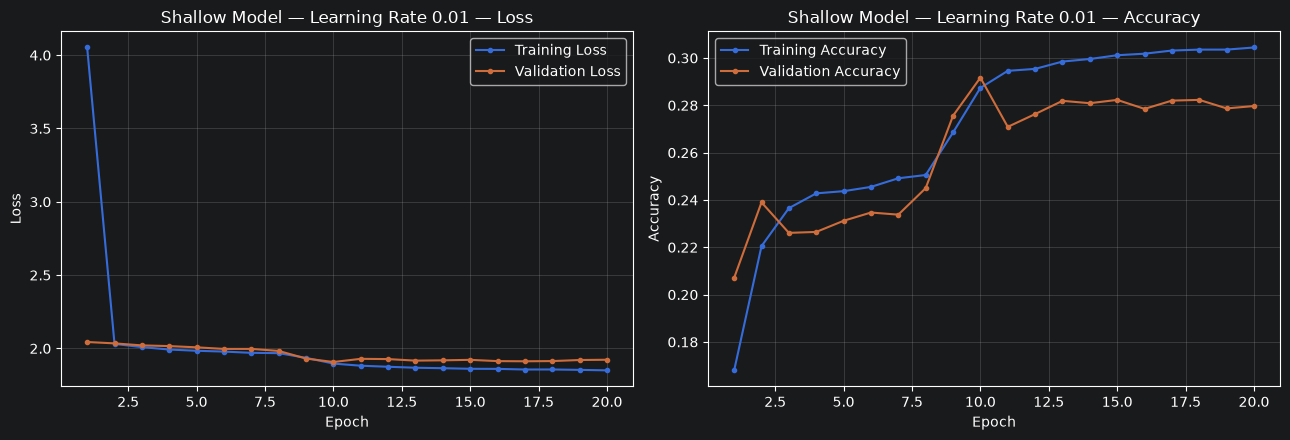

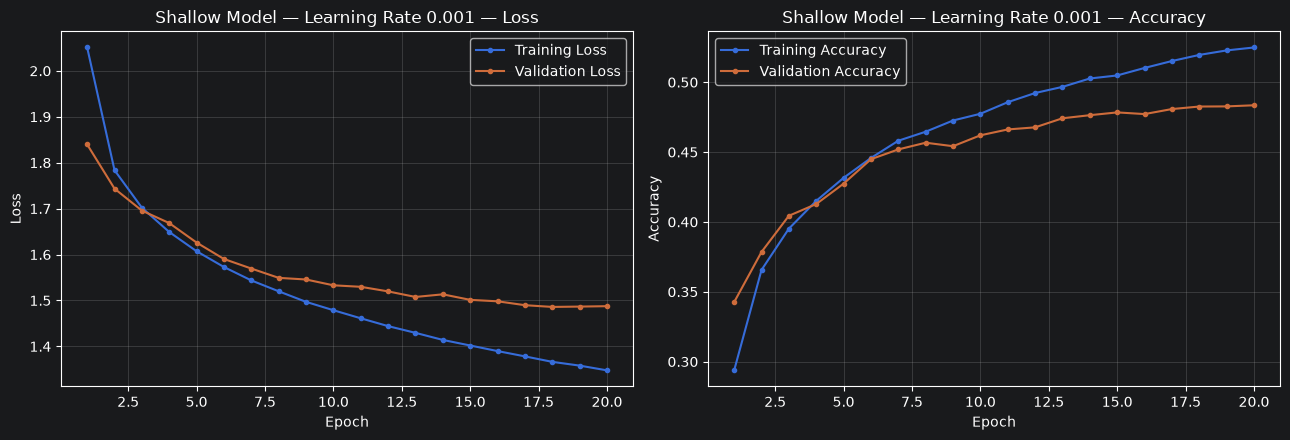

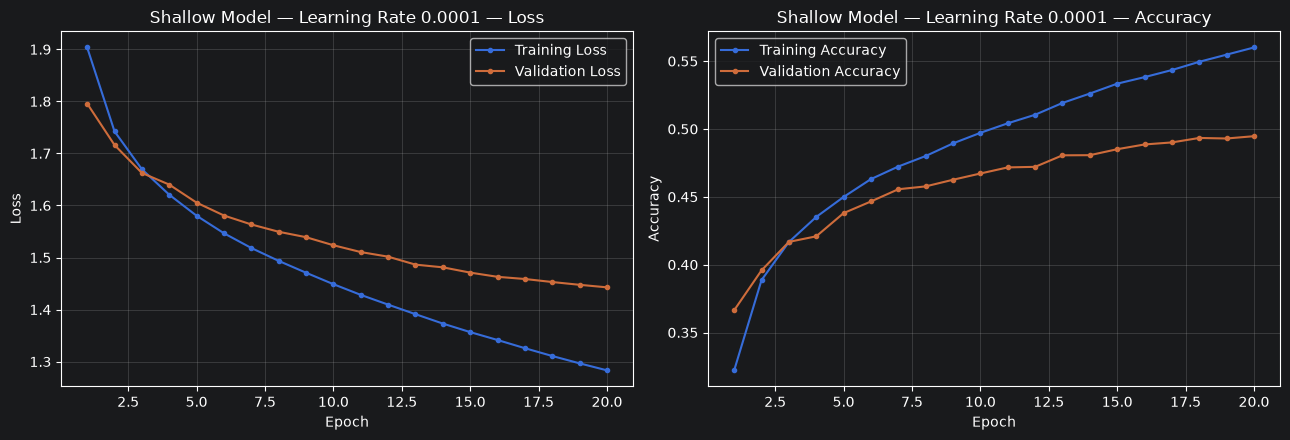

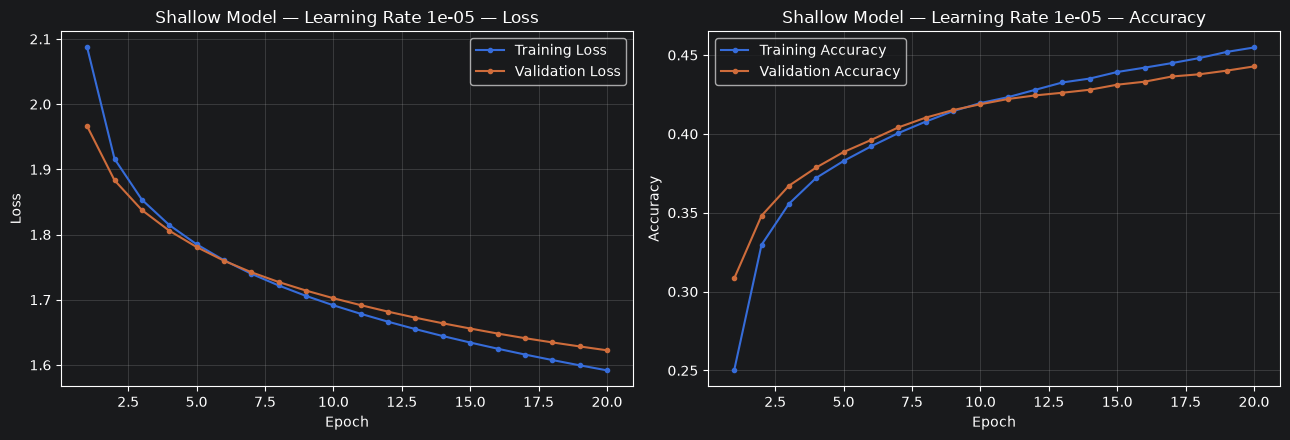

In [27]:
for lr in LEARNING_RATES:
    plot_curves(lr_histories[lr], f"Shallow Model — Learning Rate {lr}")

In [28]:
def summarize_lr(history, learning_rate):
    hist = history.history
    val_loss = np.array(hist['val_loss'])
    best = int(np.argmin(val_loss))
    reversals = int((np.diff(val_loss) > 0).sum())
    reached_40 = next((i + 1 for i, a in enumerate(hist['val_accuracy']) if a >= 0.40), None)
    return {
        'Learning Rate': learning_rate,
        'Best Epoch': best + 1,
        'Epochs to 40% Val Acc.': reached_40 if reached_40 is not None else 'never',
        'Train Loss': round(hist['loss'][best], 4),
        'Val Loss': round(float(val_loss[best]), 4),
        'Val Acc.': round(hist['val_accuracy'][best], 4),
        'Train-Val Gap': round(hist['accuracy'][best] - hist['val_accuracy'][best], 4),
        'Total Val Loss Drop': round(float(val_loss[0] - val_loss.min()), 4),
        'Val Loss Reversals': f"{reversals}/{len(val_loss) - 1}",
    }

lr_df = pd.DataFrame([summarize_lr(lr_histories[lr], lr) for lr in LEARNING_RATES])
lr_df

,Learning Rate,Best Epoch,Epochs to 40% Val Acc.,Train Loss,Val Loss,Val Acc.,Train-Val Gap,Total Val Loss Drop,Val Loss Reversals
0,0.01000,10,never,1.8967,1.9075,0.2917,-0.0043,0.1364,7/19
1,0.00100,18,3,1.3664,1.4859,0.4826,0.0370,0.3537,3/19
2,0.00010,20,3,1.2832,1.4427,0.4947,0.0654,0.3531,0/19
3,0.00001,20,7,1.5917,1.6224,0.4428,0.0120,0.3436,0/19


### Comparison

**Convergence speed.** `0.001` and `0.0001` both pass 40% validation accuracy by epoch 3, `0.00001` takes 7 epochs, and `0.01` never reaches it. `0.0001` also leads at every epoch, so it is not slower than `0.001` at any point.

**Stability.** `0.0001` and `0.00001` never regress. `0.001` regresses in 3 of 19 epoch transitions and `0.01` in 7.

**Training loss.** Lowest at `0.0001`, then `0.001`, `0.00001`, `0.01`.

**Validation loss.** Same ordering.

**Validation accuracy.** Same ordering, with `0.01` far behind the rest.

`0.01` is the only run where training accuracy stays below validation accuracy. It is not overfitting — the steps are large enough that it never fits the training set at all.

### Learning Rate Question

**Which Learning Rate is most appropriate for your model, and what evidence supports your decision?**

`0.0001`. It records the lowest training loss, the lowest validation loss and the highest validation accuracy of the four, and its validation loss never increases across the run. It also leads at every epoch, so the improvement costs nothing in convergence speed.

The extra run at `0.00001` confirms this is a real optimum rather than the edge of the tested range, since going an order of magnitude lower reverses the trend. `0.01` fails outright.

This corrects a setting inherited from Parts 3-8, which all used `0.001`. `0.0001` is carried forward into Part 10.

---
# Part 10 — Batch Size Experiment

The Batch Size sets how many images the model sees before each weight update. It changes two things at once: how many updates the model receives per epoch, and how reliable each of those updates is.

Carrying forward `0.0001` from Part 9, we compare `16`, `32` and `64` as required, plus `128` — the value used throughout Parts 3-9 — so the comparison connects to the earlier results.

The architecture, Learning Rate, epoch count, data and seed are unchanged. Wall-clock time is recorded per run, since training speed is one of the criteria being compared.

In [29]:
import time

BEST_LEARNING_RATE = 0.0001
BATCH_SIZES = [16, 32, 64, 128]

def build_shallow_batch():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_batch_model')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=BEST_LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

batch_histories = {}
batch_seconds = {}

In [30]:
print("Batch Size = 16")
batch_model_16 = build_shallow_batch()
started = time.time()
batch_histories[16] = batch_model_16.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=16,
    verbose=2
)
batch_seconds[16] = time.time() - started

Batch Size = 16
Epoch 1/20
2500/2500 - 9s - 3ms/step - accuracy: 0.3353 - loss: 1.8618 - val_accuracy: 0.3708 - val_loss: 1.7914
Epoch 2/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4008 - loss: 1.6877 - val_accuracy: 0.4055 - val_loss: 1.6752
Epoch 3/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4288 - loss: 1.6092 - val_accuracy: 0.4241 - val_loss: 1.6342
Epoch 4/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4483 - loss: 1.5547 - val_accuracy: 0.4368 - val_loss: 1.6026
Epoch 5/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4668 - loss: 1.5098 - val_accuracy: 0.4428 - val_loss: 1.5885
Epoch 6/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4814 - loss: 1.4700 - val_accuracy: 0.4536 - val_loss: 1.5514
Epoch 7/20
2500/2500 - 8s - 3ms/step - accuracy: 0.4941 - loss: 1.4373 - val_accuracy: 0.4621 - val_loss: 1.5392
Epoch 8/20
2500/2500 - 8s - 3ms/step - accuracy: 0.5061 - loss: 1.4064 - val_accuracy: 0.4657 - val_loss: 1.5302
Epoch 9/20
2500/2500 - 8s - 3ms/step - accuracy: 0.5170 - loss: 1.3776 - val_acc

In [31]:
print("Batch Size = 32")
batch_model_32 = build_shallow_batch()
started = time.time()
batch_histories[32] = batch_model_32.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=32,
    verbose=2
)
batch_seconds[32] = time.time() - started

Batch Size = 32
Epoch 1/20
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/20
1250/1250 - 4s - 3ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/20
1250/1250 - 4s - 3ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/20
1250/1250 - 4s - 3ms/step - accuracy: 0.5091 - loss: 1.4018 - val_acc

In [32]:
print("Batch Size = 64")
batch_model_64 = build_shallow_batch()
started = time.time()
batch_histories[64] = batch_model_64.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=64,
    verbose=2
)
batch_seconds[64] = time.time() - started

Batch Size = 64
Epoch 1/20
625/625 - 3s - 4ms/step - accuracy: 0.3271 - loss: 1.8855 - val_accuracy: 0.3843 - val_loss: 1.7659
Epoch 2/20
625/625 - 2s - 4ms/step - accuracy: 0.3941 - loss: 1.7226 - val_accuracy: 0.4115 - val_loss: 1.6907
Epoch 3/20
625/625 - 2s - 4ms/step - accuracy: 0.4209 - loss: 1.6473 - val_accuracy: 0.4273 - val_loss: 1.6384
Epoch 4/20
625/625 - 2s - 4ms/step - accuracy: 0.4387 - loss: 1.5948 - val_accuracy: 0.4431 - val_loss: 1.6006
Epoch 5/20
625/625 - 3s - 4ms/step - accuracy: 0.4558 - loss: 1.5536 - val_accuracy: 0.4488 - val_loss: 1.5797
Epoch 6/20
625/625 - 3s - 4ms/step - accuracy: 0.4694 - loss: 1.5197 - val_accuracy: 0.4613 - val_loss: 1.5464
Epoch 7/20
625/625 - 3s - 4ms/step - accuracy: 0.4810 - loss: 1.4887 - val_accuracy: 0.4654 - val_loss: 1.5324
Epoch 8/20
625/625 - 3s - 4ms/step - accuracy: 0.4920 - loss: 1.4598 - val_accuracy: 0.4736 - val_loss: 1.5151
Epoch 9/20
625/625 - 3s - 4ms/step - accuracy: 0.4987 - loss: 1.4362 - val_accuracy: 0.4802 - va

In [33]:
print("Batch Size = 128")
batch_model_128 = build_shallow_batch()
started = time.time()
batch_histories[128] = batch_model_128.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=128,
    verbose=2
)
batch_seconds[128] = time.time() - started

Batch Size = 128
Epoch 1/20
313/313 - 2s - 6ms/step - accuracy: 0.3221 - loss: 1.9035 - val_accuracy: 0.3664 - val_loss: 1.7958
Epoch 2/20
313/313 - 1s - 5ms/step - accuracy: 0.3886 - loss: 1.7423 - val_accuracy: 0.3958 - val_loss: 1.7162
Epoch 3/20
313/313 - 1s - 5ms/step - accuracy: 0.4167 - loss: 1.6696 - val_accuracy: 0.4168 - val_loss: 1.6624
Epoch 4/20
313/313 - 1s - 5ms/step - accuracy: 0.4352 - loss: 1.6206 - val_accuracy: 0.4209 - val_loss: 1.6401
Epoch 5/20
313/313 - 1s - 5ms/step - accuracy: 0.4499 - loss: 1.5803 - val_accuracy: 0.4380 - val_loss: 1.6054
Epoch 6/20
313/313 - 1s - 5ms/step - accuracy: 0.4631 - loss: 1.5466 - val_accuracy: 0.4466 - val_loss: 1.5807
Epoch 7/20
313/313 - 1s - 5ms/step - accuracy: 0.4724 - loss: 1.5183 - val_accuracy: 0.4556 - val_loss: 1.5635
Epoch 8/20
313/313 - 1s - 5ms/step - accuracy: 0.4801 - loss: 1.4935 - val_accuracy: 0.4577 - val_loss: 1.5494
Epoch 9/20
313/313 - 1s - 5ms/step - accuracy: 0.4894 - loss: 1.4708 - val_accuracy: 0.4626 - v

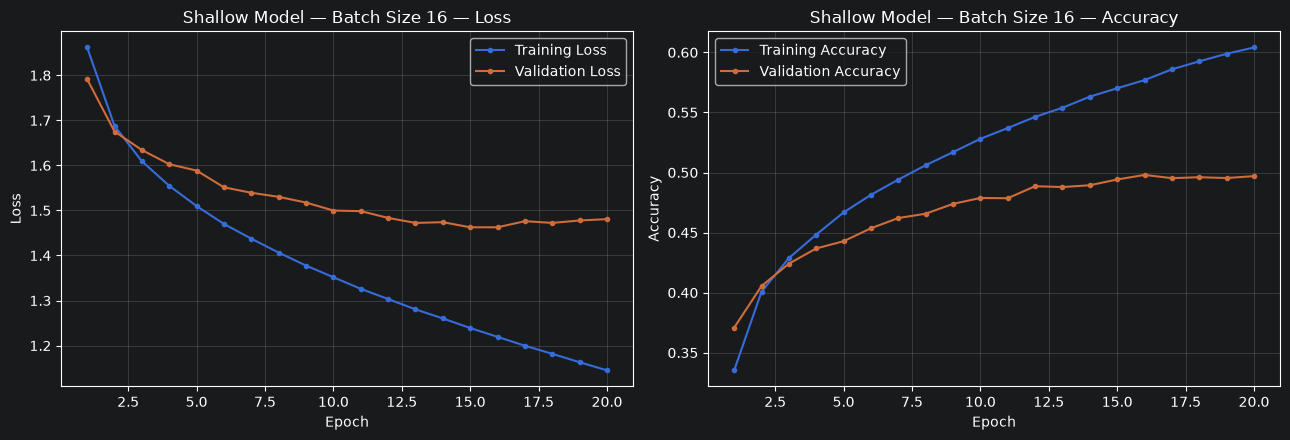

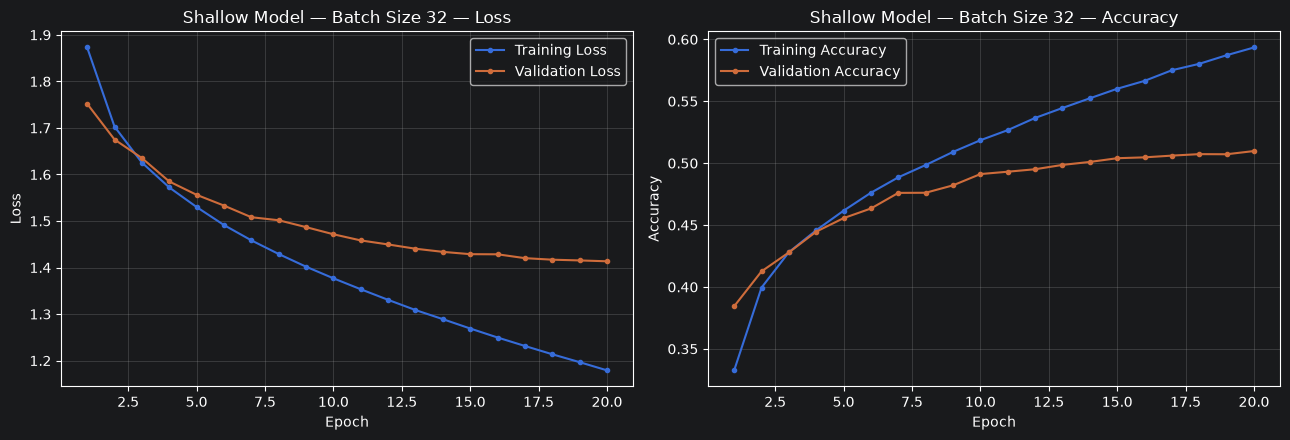

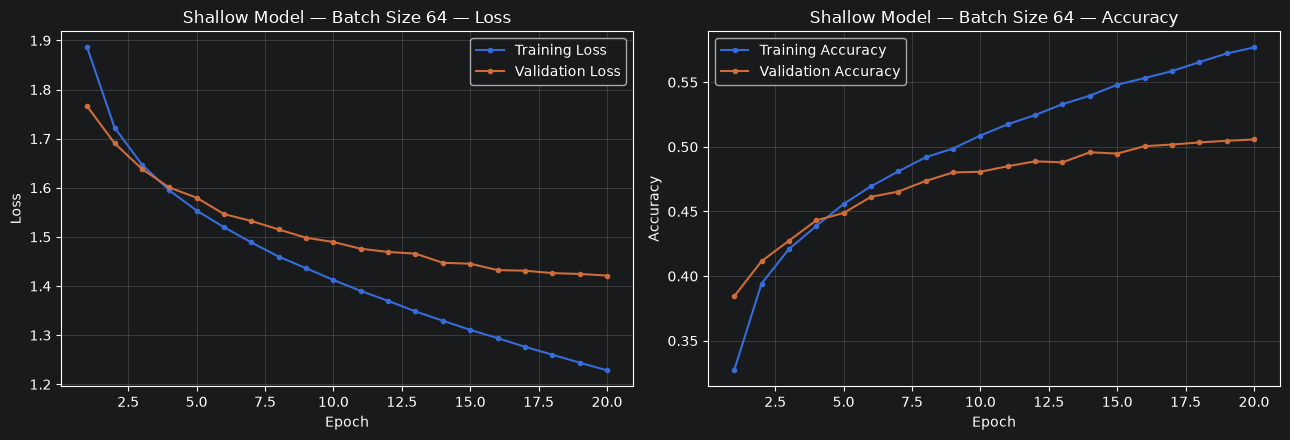

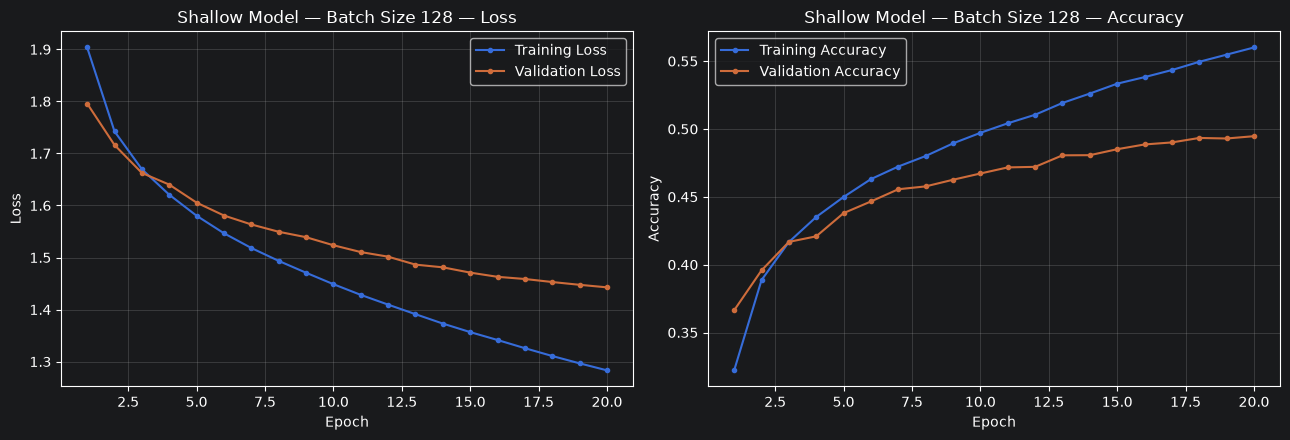

In [34]:
for batch_size in BATCH_SIZES:
    plot_curves(batch_histories[batch_size], f"Shallow Model — Batch Size {batch_size}")

In [35]:
def summarize_batch(history, batch_size, seconds):
    hist = history.history
    val_loss = np.array(hist['val_loss'])
    best = int(np.argmin(val_loss))
    reversals = int((np.diff(val_loss) > 0).sum())
    steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
    return {
        'Batch Size': batch_size,
        'Steps per Epoch': steps_per_epoch,
        'Total Updates': steps_per_epoch * EPOCHS,
        'Best Epoch': best + 1,
        'Train Acc.': round(hist['accuracy'][best], 4),
        'Val Acc.': round(hist['val_accuracy'][best], 4),
        'Val Loss': round(float(val_loss[best]), 4),
        'Train-Val Gap': round(hist['accuracy'][best] - hist['val_accuracy'][best], 4),
        'Val Loss Reversals': f"{reversals}/{len(val_loss) - 1}",
        'Seconds': round(seconds, 1),
        'Sec / Epoch': round(seconds / EPOCHS, 2),
    }

batch_df = pd.DataFrame([
    summarize_batch(batch_histories[b], b, batch_seconds[b]) for b in BATCH_SIZES
])
batch_df

,Batch Size,Steps per Epoch,Total Updates,Best Epoch,Train Acc.,Val Acc.,Val Loss,Train-Val Gap,Val Loss Reversals,Seconds,Sec / Epoch
0,16,2500,50000,15,0.5702,0.4942,1.4626,0.0760,5/19,166.1,8.30
1,32,1250,25000,20,0.5935,0.5098,1.4134,0.0836,0/19,86.1,4.31
2,64,625,12500,20,0.5769,0.5057,1.4213,0.0712,0/19,50.1,2.50
3,128,313,6260,20,0.5601,0.4947,1.4427,0.0654,0/19,29.1,1.45


### Comparison

**Training behavior.** Batch 16 receives eight times as many weight updates as batch 128 and is the only run whose validation loss stops improving before the end: it bottoms out at epoch 15 and then flattens, drifting inside a narrow band for the remaining epochs without recovering. The other three are still descending at epoch 20.

**Training speed.** Roughly 1.4 seconds per epoch at batch 128, approximately doubling with each halving of the batch, up to 8.3 at batch 16 — about six times the total cost, for a worse result.

**Curve stability.** Batch 16 is the only run whose validation loss ever moves backwards, in 5 of 19 transitions. Batches 32, 64 and 128 descend without a single reversal, since each of their updates is estimated from more images and is correspondingly less noisy.

**Validation performance.** Batch 32 is highest, with 64 immediately behind it, and 16 and 128 clearly lower. The best result sits in the middle of the tested range rather than at either end.

**Generalization gap.** The gap is widest at batch 32, which at first appears to argue against it. It does not. A small gap is not itself the goal — the `0.01` run in Part 9 produced the smallest gap in this notebook while being the worst model, because a model that fits nothing fits both sets equally badly. Batch 32's wider gap comes from training further rather than generalizing worse: it has the highest training *and* the highest validation accuracy, and its validation loss is still falling at the final epoch. Batch 16 is not overfitting either — its validation loss flattens after epoch 15 rather than rising — but it has stopped making progress, which batch 32 has not.

### Batch Size Questions

**Which Batch Size produced the best result?**
Batch `32`, on both validation metrics, with `64` immediately behind it. The margin between those two is smaller than the variation produced by changing the random seed alone, so this experiment separates them from `16` and `128` but cannot reliably separate them from each other. The dependable finding is that the middle of the range beats both ends. `32` is carried forward as the better of the two on the measured figures.

**Did increasing Batch Size automatically improve the model?**
No, and neither did decreasing it. Performance improves as the batch falls from 128 to 64 to 32, then reverses at 16, so the relationship is an inverted U with its peak in the middle. Batch 16 makes the point: it receives eight times as many updates as batch 128 and costs six times as much to train, yet still finishes behind it. More updates do not mean more learning when each update is estimated from too few images to point reliably downhill.

**What effect did Batch Size have on the learning curves?**
Smaller batches made the curves both noisier and faster-moving. Batch 16 is the only run that regresses at all, and the only one whose curve flattens before training ends. The larger batches produced smooth curves that were still improving at epoch 20.

---
# Part 11 — Optimizer Experiment

Backpropagation computes the gradients; the optimizer decides how those gradients are turned into weight updates. We compare Adam against SGD on the selected architecture.

Adam is used at `0.0001`, the rate selected in Part 9. SGD is given its own search over `0.1`, `0.01` and `0.001`, because a rate tuned for one optimizer is not a fair setting for the other. Everything else — architecture, batch size 32, epochs, data and seed — is unchanged.

In [36]:
BEST_BATCH_SIZE = 32

def build_shallow_optimizer(optimizer):
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', name='hidden_1'),
        layers.Dense(10, activation='softmax', name='output')
    ], name='shallow_optimizer_model')

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

optimizer_histories = {}

In [37]:
print("Adam (lr=0.0001)")
opt_model_adam = build_shallow_optimizer(keras.optimizers.Adam(learning_rate=0.0001))
optimizer_histories['Adam (lr=0.0001)'] = opt_model_adam.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Adam (lr=0.0001)
Epoch 1/20
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/20
1250/1250 - 5s - 4ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/20
1250/1250 - 5s - 4ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/20
1250/1250 - 5s - 4ms/step - accuracy: 0.5091 - loss: 1.4018 - val_ac

In [38]:
print("SGD (lr=0.1)")
opt_model_sgd1 = build_shallow_optimizer(keras.optimizers.SGD(learning_rate=0.1))
optimizer_histories['SGD (lr=0.1)'] = opt_model_sgd1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

SGD (lr=0.1)
Epoch 1/20
1250/1250 - 2s - 2ms/step - accuracy: 0.2755 - loss: 1.9902 - val_accuracy: 0.3188 - val_loss: 1.8562
Epoch 2/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3415 - loss: 1.8298 - val_accuracy: 0.3700 - val_loss: 1.7516
Epoch 3/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3704 - loss: 1.7545 - val_accuracy: 0.3945 - val_loss: 1.6899
Epoch 4/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3900 - loss: 1.7094 - val_accuracy: 0.4069 - val_loss: 1.6712
Epoch 5/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4024 - loss: 1.6738 - val_accuracy: 0.4247 - val_loss: 1.6345
Epoch 6/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4154 - loss: 1.6450 - val_accuracy: 0.4207 - val_loss: 1.6466
Epoch 7/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4210 - loss: 1.6218 - val_accuracy: 0.4199 - val_loss: 1.6537
Epoch 8/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4333 - loss: 1.5968 - val_accuracy: 0.4240 - val_loss: 1.6491
Epoch 9/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4435 - loss: 1.5717 - val_accura

In [39]:
print("SGD (lr=0.01)")
opt_model_sgd2 = build_shallow_optimizer(keras.optimizers.SGD(learning_rate=0.01))
optimizer_histories['SGD (lr=0.01)'] = opt_model_sgd2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

SGD (lr=0.01)
Epoch 1/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3285 - loss: 1.8815 - val_accuracy: 0.3809 - val_loss: 1.7577
Epoch 2/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3995 - loss: 1.7089 - val_accuracy: 0.4112 - val_loss: 1.6761
Epoch 3/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4271 - loss: 1.6317 - val_accuracy: 0.4301 - val_loss: 1.6245
Epoch 4/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4451 - loss: 1.5782 - val_accuracy: 0.4404 - val_loss: 1.5900
Epoch 5/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4609 - loss: 1.5363 - val_accuracy: 0.4515 - val_loss: 1.5660
Epoch 6/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4746 - loss: 1.5012 - val_accuracy: 0.4590 - val_loss: 1.5429
Epoch 7/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4857 - loss: 1.4704 - val_accuracy: 0.4629 - val_loss: 1.5282
Epoch 8/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4965 - loss: 1.4431 - val_accuracy: 0.4702 - val_loss: 1.5118
Epoch 9/20
1250/1250 - 2s - 2ms/step - accuracy: 0.5059 - loss: 1.4177 - val_accur

In [40]:
print("SGD (lr=0.001)")
opt_model_sgd3 = build_shallow_optimizer(keras.optimizers.SGD(learning_rate=0.001))
optimizer_histories['SGD (lr=0.001)'] = opt_model_sgd3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

SGD (lr=0.001)
Epoch 1/20
1250/1250 - 2s - 2ms/step - accuracy: 0.2602 - loss: 2.0597 - val_accuracy: 0.3105 - val_loss: 1.9503
Epoch 2/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3347 - loss: 1.9046 - val_accuracy: 0.3427 - val_loss: 1.8730
Epoch 3/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3579 - loss: 1.8461 - val_accuracy: 0.3618 - val_loss: 1.8306
Epoch 4/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3730 - loss: 1.8094 - val_accuracy: 0.3750 - val_loss: 1.8011
Epoch 5/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3839 - loss: 1.7823 - val_accuracy: 0.3856 - val_loss: 1.7785
Epoch 6/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3913 - loss: 1.7601 - val_accuracy: 0.3912 - val_loss: 1.7595
Epoch 7/20
1250/1250 - 2s - 2ms/step - accuracy: 0.3975 - loss: 1.7410 - val_accuracy: 0.3983 - val_loss: 1.7431
Epoch 8/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4038 - loss: 1.7242 - val_accuracy: 0.4027 - val_loss: 1.7288
Epoch 9/20
1250/1250 - 2s - 2ms/step - accuracy: 0.4103 - loss: 1.7091 - val_accu

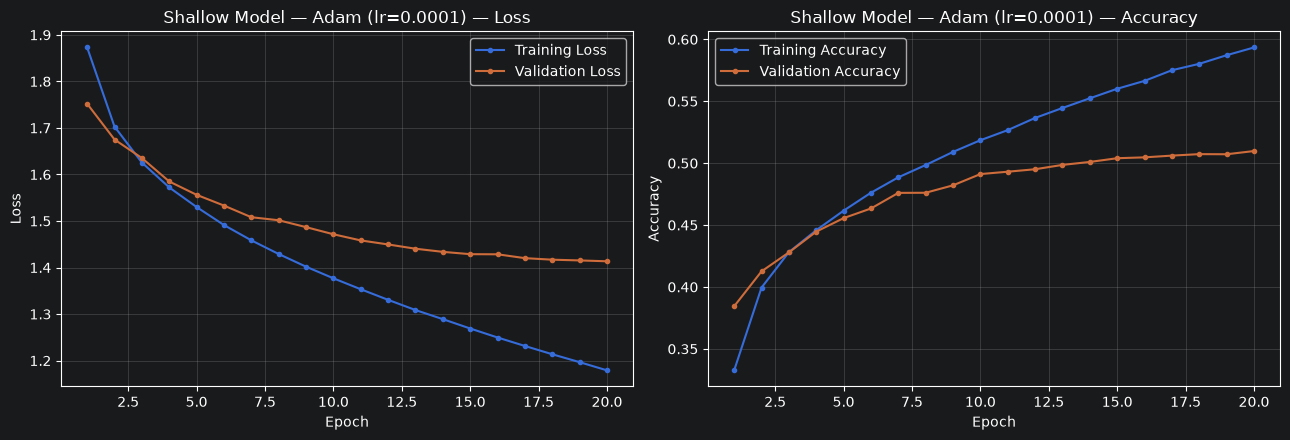

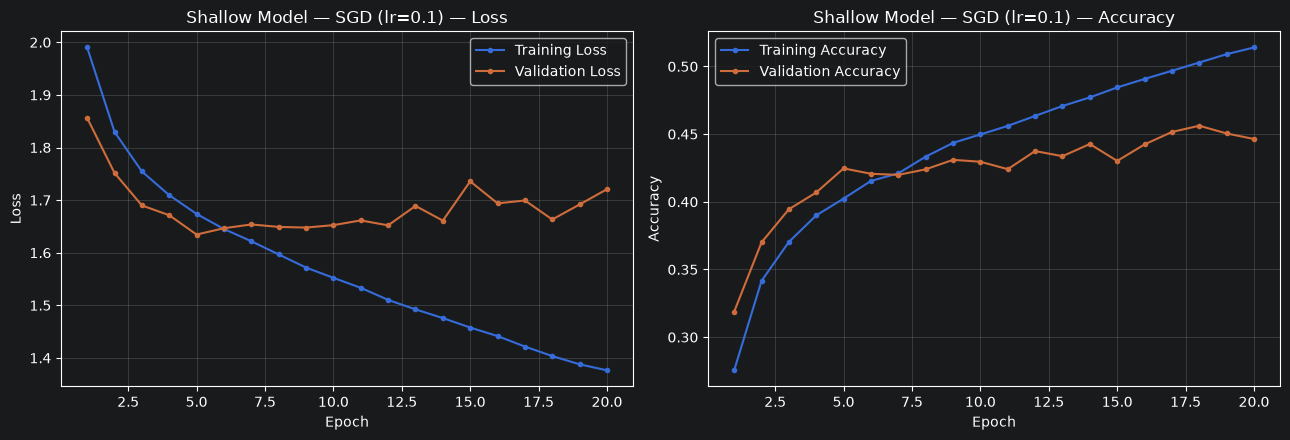

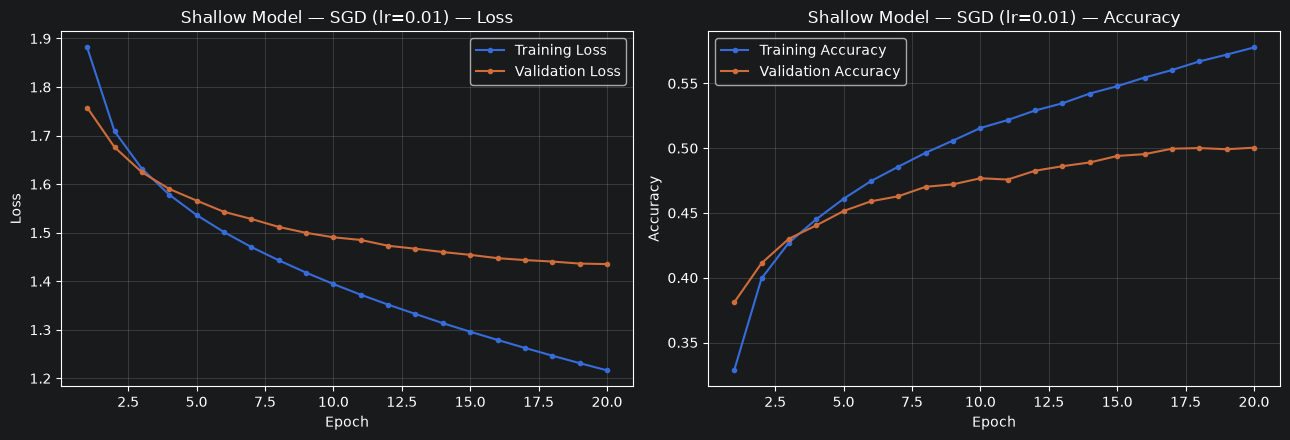

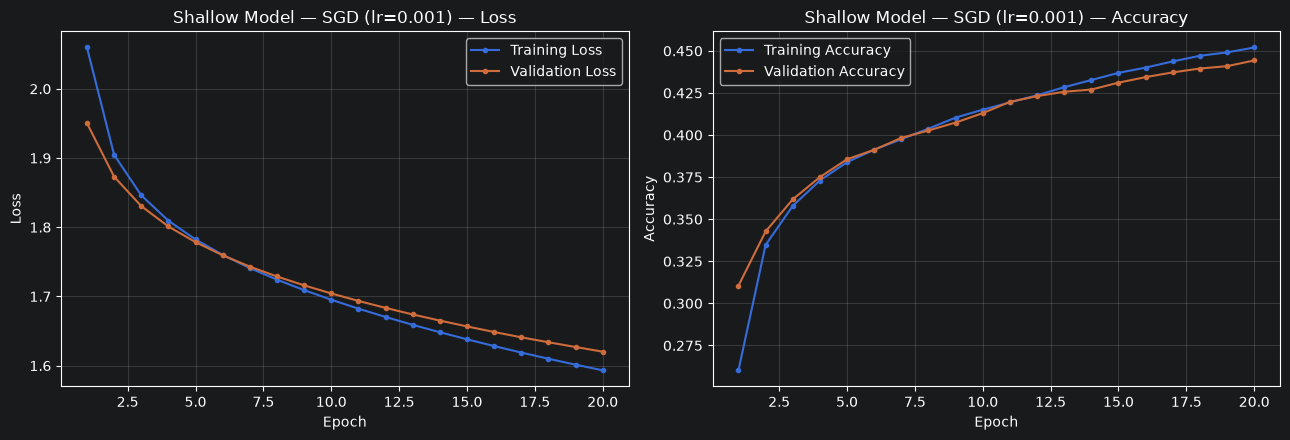

In [41]:
for label in optimizer_histories:
    plot_curves(optimizer_histories[label], f"Shallow Model — {label}")

In [42]:
def summarize_optimizer(history, label):
    hist = history.history
    val_loss = np.array(hist['val_loss'])
    best = int(np.argmin(val_loss))
    reversals = int((np.diff(val_loss) > 0).sum())
    reached_40 = next((i + 1 for i, a in enumerate(hist['val_accuracy']) if a >= 0.40), None)
    return {
        'Run': label,
        'Best Epoch': best + 1,
        'Epochs to 40% Val Acc.': reached_40 if reached_40 is not None else 'never',
        'Train Loss': round(hist['loss'][best], 4),
        'Val Loss': round(float(val_loss[best]), 4),
        'Val Acc.': round(hist['val_accuracy'][best], 4),
        'Val Loss Reversals': f"{reversals}/{len(val_loss) - 1}",
    }

optimizer_df = pd.DataFrame([summarize_optimizer(optimizer_histories[l], l)
                             for l in optimizer_histories])
optimizer_df

,Run,Best Epoch,Epochs to 40% Val Acc.,Train Loss,Val Loss,Val Acc.,Val Loss Reversals
0,Adam (lr=0.0001),20,2,1.1790,1.4134,0.5098,0/19
1,SGD (lr=0.1),5,4,1.6738,1.6345,0.4247,9/19
2,SGD (lr=0.01),20,2,1.2164,1.4352,0.5004,0/19
3,SGD (lr=0.001),20,8,1.5932,1.6202,0.4443,0/19


### Comparison

**Speed of convergence.** Adam and SGD at `0.01` both pass 40% validation accuracy by epoch 2. SGD at `0.1` needs 4 epochs and SGD at `0.001` needs 8. In wall-clock terms SGD is roughly twice as fast per epoch, since it keeps no per-weight state.

**Stability.** At their own best rates both optimizers are equally stable, with no epoch in which validation loss increases. SGD at `0.1` regresses in 9 of 19 transitions, so that instability belongs to the step size rather than to the optimizer.

**Final validation performance.** Adam reaches ~0.510 and SGD at `0.01` reaches ~0.500, with the other two SGD rates well behind.

### Optimizer Question

**Which optimizer would you select and why?**

Adam. At its own best rate it records the highest validation accuracy and the lowest validation loss, although its margin over SGD at `0.01` is about one percentage point and the two are equally stable, so they are close.

The stronger result is that the two optimizers require very different step sizes — `0.0001` for Adam and `0.01` for SGD, a factor of 100 apart — and each looks broken when given the other's. SGD drops to ~0.444 at `0.001`, and Adam drops to ~0.292 at `0.01` in Part 9. An optimizer comparison is only meaningful once each has been given a rate suited to it.

Adam is carried forward. Beyond the slightly better result, it adapts its step size per weight, which matters in Parts 12-14 where Dropout, L2 and Batch Normalization change the loss surface and a fixed SGD rate would likely need re-tuning after each change.

---
# Part 12 — Regularization Experiments

Regularization targets generalization rather than training accuracy, so it can only be measured where the model actually overfits. At the 20-epoch budget used so far the selected model is still improving and has not begun to overfit, so these experiments are run for 30 epochs — far enough past the point where validation loss flattens for the effect of each technique to be visible.

All five runs share the same architecture, Learning Rate, batch size, optimizer, data and seed, and the same 30-epoch budget. Only the regularization differs.

- **A — No regularization:** the control.
- **B — Dropout:** `0.2` and `0.5`, placed between the hidden layer and the output.
- **C — Early Stopping:** monitors validation loss with `restore_best_weights=True`.
- **D — L2:** applied to the Dense kernels, where almost all of the parameters are.

Each is judged on validation performance and the generalization gap, not on training accuracy — every one of these techniques is expected to reduce training accuracy by design.

In [43]:
REG_EPOCHS = 30

def build_regularized(dropout=None, l2=None):
    keras.utils.set_random_seed(SEED)
    kernel_reg = keras.regularizers.l2(l2) if l2 else None

    stack = [
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation='relu', kernel_regularizer=kernel_reg, name='hidden_1')
    ]
    if dropout:
        stack.append(layers.Dropout(dropout, name='dropout'))
    stack.append(layers.Dense(10, activation='softmax', kernel_regularizer=kernel_reg, name='output'))

    model = keras.Sequential(stack, name='shallow_regularized_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=BEST_LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

reg_histories = {}

In [44]:
print("Experiment A - No regularization")
model_a = build_regularized()
reg_histories['A - No regularization'] = model_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Experiment A - No regularization
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5091 - loss:

In [45]:
print("Experiment B - Dropout 0.2")
model_b1 = build_regularized(dropout=0.2)
reg_histories['B - Dropout 0.2'] = model_b1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Experiment B - Dropout 0.2
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3159 - loss: 1.9101 - val_accuracy: 0.3750 - val_loss: 1.7663
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3808 - loss: 1.7471 - val_accuracy: 0.4124 - val_loss: 1.6804
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4056 - loss: 1.6781 - val_accuracy: 0.4345 - val_loss: 1.6219
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4284 - loss: 1.6265 - val_accuracy: 0.4473 - val_loss: 1.5881
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4416 - loss: 1.5901 - val_accuracy: 0.4591 - val_loss: 1.5587
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4492 - loss: 1.5572 - val_accuracy: 0.4646 - val_loss: 1.5409
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4631 - loss: 1.5301 - val_accuracy: 0.4702 - val_loss: 1.5192
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4740 - loss: 1.5023 - val_accuracy: 0.4739 - val_loss: 1.5010
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4816 - loss: 1.479

In [46]:
print("Experiment B - Dropout 0.5")
model_b2 = build_regularized(dropout=0.5)
reg_histories['B - Dropout 0.5'] = model_b2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Experiment B - Dropout 0.5
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.2763 - loss: 1.9909 - val_accuracy: 0.3585 - val_loss: 1.8272
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3388 - loss: 1.8451 - val_accuracy: 0.3808 - val_loss: 1.7586
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3638 - loss: 1.7901 - val_accuracy: 0.3968 - val_loss: 1.7123
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3812 - loss: 1.7516 - val_accuracy: 0.4056 - val_loss: 1.6771
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3907 - loss: 1.7168 - val_accuracy: 0.4232 - val_loss: 1.6453
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4018 - loss: 1.6924 - val_accuracy: 0.4308 - val_loss: 1.6270
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4101 - loss: 1.6737 - val_accuracy: 0.4370 - val_loss: 1.6223
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4159 - loss: 1.6536 - val_accuracy: 0.4448 - val_loss: 1.5916
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4228 - loss: 1.635

In [47]:
print("Experiment C - Early Stopping")
model_c = build_regularized()
reg_histories['C - Early Stopping'] = model_c.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                             restore_best_weights=True)],
    verbose=2
)

Experiment C - Early Stopping
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/30
1250/1250 - 4s - 3ms/step - accuracy: 0.5091 - loss: 1.

In [48]:
print("Experiment D - L2 1e-4")
model_d = build_regularized(l2=1e-4)
reg_histories['D - L2 1e-4'] = model_d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=REG_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Experiment D - L2 1e-4
Epoch 1/30
1250/1250 - 6s - 5ms/step - accuracy: 0.3339 - loss: 1.9577 - val_accuracy: 0.3836 - val_loss: 1.8380
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3964 - loss: 1.7852 - val_accuracy: 0.4116 - val_loss: 1.7543
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4260 - loss: 1.7033 - val_accuracy: 0.4267 - val_loss: 1.7022
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4438 - loss: 1.6467 - val_accuracy: 0.4406 - val_loss: 1.6572
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4595 - loss: 1.5988 - val_accuracy: 0.4513 - val_loss: 1.6265
Epoch 6/30
1250/1250 - 6s - 5ms/step - accuracy: 0.4726 - loss: 1.5606 - val_accuracy: 0.4638 - val_loss: 1.5962
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4848 - loss: 1.5266 - val_accuracy: 0.4717 - val_loss: 1.5686
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4941 - loss: 1.4979 - val_accuracy: 0.4804 - val_loss: 1.5507
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5062 - loss: 1.4706 - 

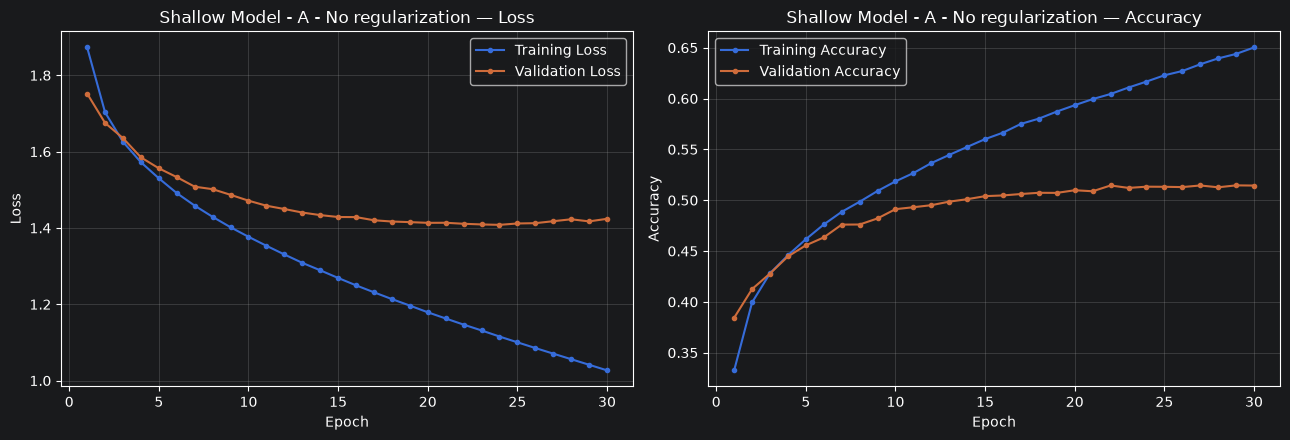

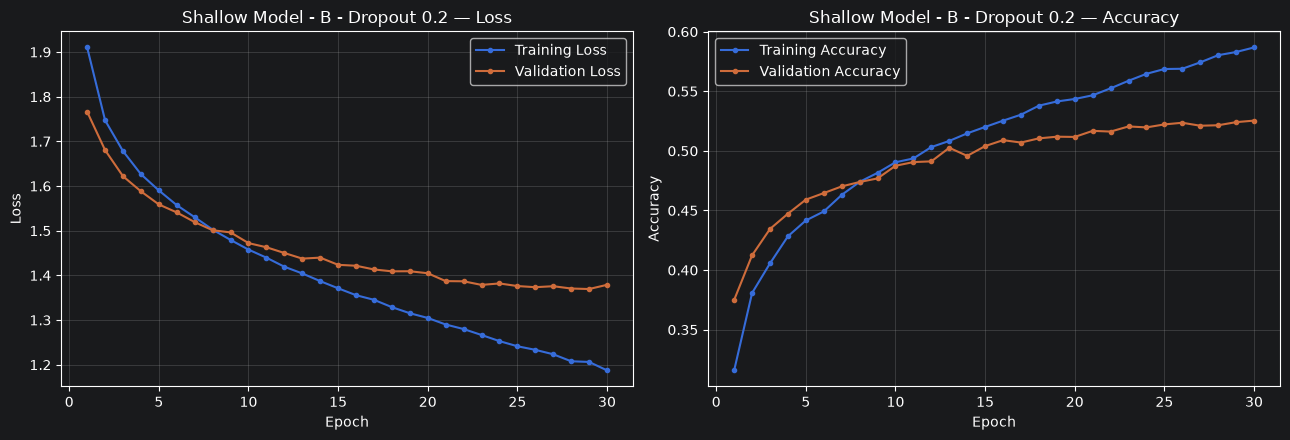

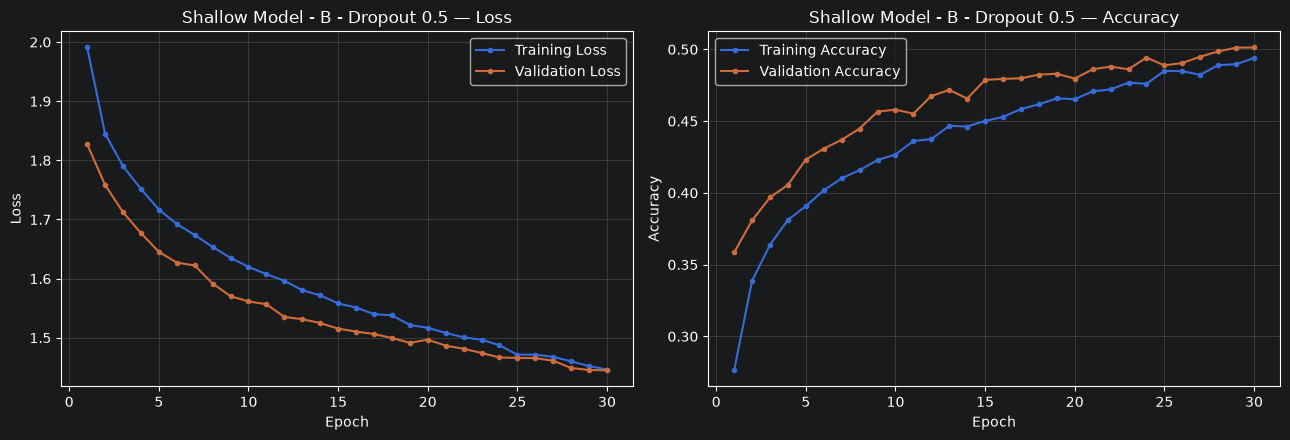

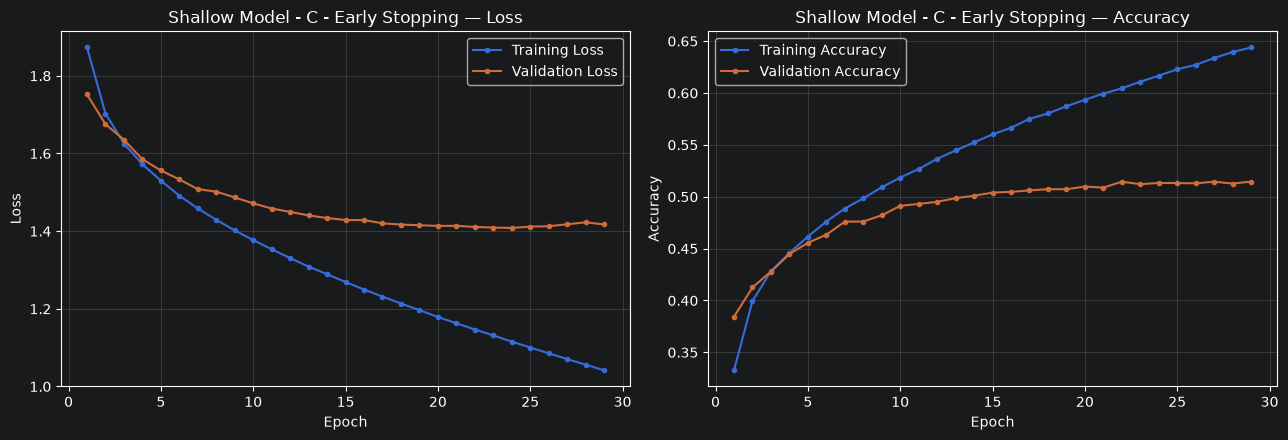

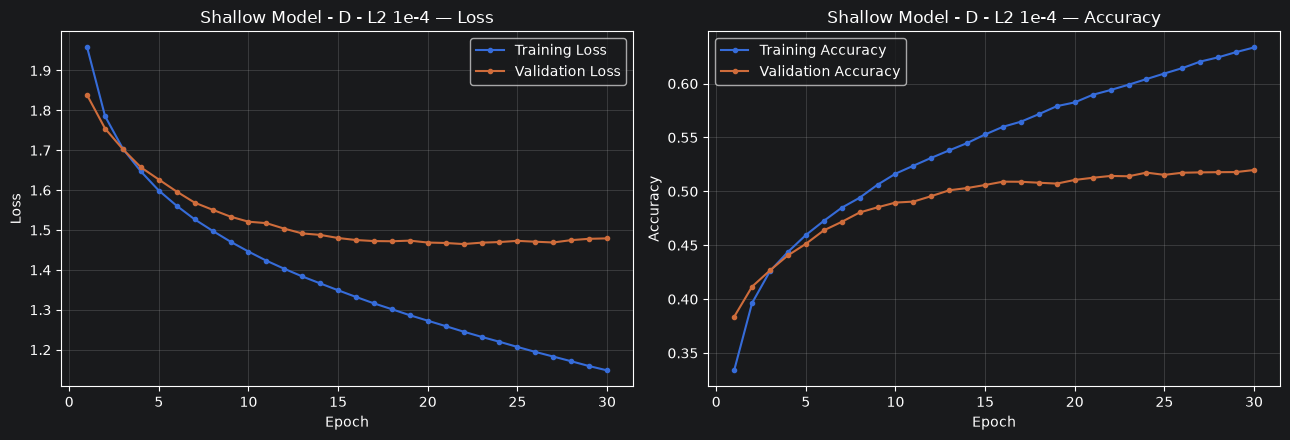

In [49]:
for reg_label in reg_histories:
    plot_curves(reg_histories[reg_label], f"Shallow Model - {reg_label}")

In [50]:
def summarize_regularization(history, label):
    hist = history.history
    val_loss = np.array(hist['val_loss'])
    best = int(np.argmin(val_loss))
    return {
        'Experiment': label,
        'Epochs Run': len(val_loss),
        'Best Epoch': best + 1,
        'Train Acc.': round(hist['accuracy'][best], 4),
        'Val Acc.': round(hist['val_accuracy'][best], 4),
        'Val Loss': round(float(val_loss[best]), 4),
        'Generalization Gap': round(hist['accuracy'][best] - hist['val_accuracy'][best], 4),
        'Final Train Acc.': round(hist['accuracy'][-1], 4),
        'Final Val Acc.': round(hist['val_accuracy'][-1], 4),
    }

regularization_df = pd.DataFrame([summarize_regularization(reg_histories[l], l)
                                  for l in reg_histories])
regularization_df

,Experiment,Epochs Run,Best Epoch,Train Acc.,Val Acc.,Val Loss,Generalization Gap,Final Train Acc.,Final Val Acc.
0,A - No regularization,30,24,0.6167,0.5133,1.4081,0.1034,0.6502,0.5144
1,B - Dropout 0.2,30,29,0.5829,0.5241,1.3694,0.0588,0.5867,0.5254
2,B - Dropout 0.5,30,30,0.4939,0.5013,1.4449,-0.0074,0.4939,0.5013
3,C - Early Stopping,29,24,0.6167,0.5133,1.4081,0.1034,0.6439,0.5146
4,D - L2 1e-4,30,22,0.5940,0.5143,1.4648,0.0797,0.6335,0.5198


### Comparison

**Training performance.** Every technique lowers training accuracy relative to the unregularized baseline (0.6167) — L2 to 0.5940, Dropout 0.2 to 0.5829, Dropout 0.5 to 0.4939. This is the intended behaviour and is not evidence against any of them.

**Validation performance.** Dropout 0.2 is the only run that clearly improves on the baseline, reaching 0.5241 against 0.5133 and recording the lowest validation loss of the five (1.3694 against 1.4081). L2 is marginal — slightly better accuracy (0.5143) but a worse validation loss (1.4648). Dropout 0.5 is worse on both.

**Generalization gap.** The baseline's gap is 0.1034. Dropout 0.2 nearly halves it to 0.0588 while simultaneously improving validation performance, which is the combination that matters. Dropout 0.5 drives it slightly negative (-0.0074): training accuracy has fallen below validation accuracy, so the model is now underfitting rather than generalizing better.

**Learning curves.** The unregularized run reaches its best validation loss at epoch 24 and separates afterwards, with the gap widening to 0.1358 by epoch 30. Dropout 0.2 delays that turning point to epoch 29, and Dropout 0.5 never reaches one within the budget. L2 peaks earliest, at epoch 22.

**Which regularization is carried forward, and why.** Dropout 0.2, on validation loss, validation accuracy and gap together. Early Stopping is also kept: its row is identical to the baseline because both are reported at the best-validation-loss epoch, but the difference is operational — Early Stopping returns those weights automatically rather than whatever the final epoch happened to produce. L2 is excluded because it worsened validation loss, and Dropout 0.5 because it underfits.

---
# Part 13 — Training Stability Experiment

Batch Normalization standardizes the activations flowing between layers, which is intended to keep them in a stable range and make deeper networks easier to optimize. It is examined separately from Part 12 because its purpose is training stability rather than generalization.

The brief asks whether its effect is more noticeable in a deeper network, so the comparison is run on two architectures: the selected Shallow model and the Deep model from Part 4, each with and without `BatchNormalization()`. Learning Rate, batch size, optimizer, data and seed are identical across all four runs, and the 30-epoch budget introduced in Part 12 is kept for the rest of the project.

In [51]:
BN_EPOCHS = 30
SHALLOW_UNITS = [512]
DEEP_UNITS = [1024, 512, 256, 128, 64]

def build_with_bn(units_list, use_bn):
    keras.utils.set_random_seed(SEED)
    stack = [layers.Input(shape=(3072,))]

    for i, units in enumerate(units_list, start=1):
        stack.append(layers.Dense(units, name=f'hidden_{i}'))
        if use_bn:
            stack.append(layers.BatchNormalization(name=f'batchnorm_{i}'))
        stack.append(layers.Activation('relu', name=f'relu_{i}'))

    stack.append(layers.Dense(10, activation='softmax', name='output'))

    model = keras.Sequential(stack, name='batchnorm_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=BEST_LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

bn_histories = {}

In [52]:
print("Shallow without BatchNorm")
bn_model_1 = build_with_bn(SHALLOW_UNITS, use_bn=False)
bn_histories['Shallow without BatchNorm'] = bn_model_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BN_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Shallow without BatchNorm
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5091 - loss: 1.4018

In [53]:
print("Shallow with BatchNorm")
bn_model_2 = build_with_bn(SHALLOW_UNITS, use_bn=True)
bn_histories['Shallow with BatchNorm'] = bn_model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BN_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Shallow with BatchNorm
Epoch 1/30
1250/1250 - 6s - 4ms/step - accuracy: 0.4042 - loss: 1.7001 - val_accuracy: 0.3978 - val_loss: 1.7768
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4838 - loss: 1.4884 - val_accuracy: 0.4178 - val_loss: 1.7125
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5231 - loss: 1.3897 - val_accuracy: 0.4328 - val_loss: 1.6674
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5525 - loss: 1.3140 - val_accuracy: 0.4410 - val_loss: 1.6666
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5786 - loss: 1.2483 - val_accuracy: 0.4482 - val_loss: 1.6401
Epoch 6/30
1250/1250 - 6s - 5ms/step - accuracy: 0.6029 - loss: 1.1884 - val_accuracy: 0.4525 - val_loss: 1.6324
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.6255 - loss: 1.1329 - val_accuracy: 0.4580 - val_loss: 1.6278
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.6468 - loss: 1.0804 - val_accuracy: 0.4649 - val_loss: 1.6098
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.6661 - loss: 1.0300 - 

In [54]:
print("Deep without BatchNorm")
bn_model_3 = build_with_bn(DEEP_UNITS, use_bn=False)
bn_histories['Deep without BatchNorm'] = bn_model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BN_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Deep without BatchNorm
Epoch 1/30
1250/1250 - 10s - 8ms/step - accuracy: 0.3216 - loss: 1.8689 - val_accuracy: 0.3605 - val_loss: 1.7752
Epoch 2/30
1250/1250 - 9s - 7ms/step - accuracy: 0.4004 - loss: 1.6694 - val_accuracy: 0.4203 - val_loss: 1.6258
Epoch 3/30
1250/1250 - 9s - 7ms/step - accuracy: 0.4376 - loss: 1.5703 - val_accuracy: 0.4368 - val_loss: 1.5755
Epoch 4/30
1250/1250 - 9s - 7ms/step - accuracy: 0.4640 - loss: 1.5040 - val_accuracy: 0.4539 - val_loss: 1.5330
Epoch 5/30
1250/1250 - 9s - 7ms/step - accuracy: 0.4826 - loss: 1.4498 - val_accuracy: 0.4628 - val_loss: 1.5210
Epoch 6/30
1250/1250 - 9s - 7ms/step - accuracy: 0.5017 - loss: 1.4016 - val_accuracy: 0.4705 - val_loss: 1.5088
Epoch 7/30
1250/1250 - 9s - 7ms/step - accuracy: 0.5174 - loss: 1.3578 - val_accuracy: 0.4787 - val_loss: 1.4964
Epoch 8/30
1250/1250 - 9s - 7ms/step - accuracy: 0.5346 - loss: 1.3130 - val_accuracy: 0.4777 - val_loss: 1.5023
Epoch 9/30
1250/1250 - 9s - 7ms/step - accuracy: 0.5504 - loss: 1.2688 -

In [55]:
print("Deep with BatchNorm")
bn_model_4 = build_with_bn(DEEP_UNITS, use_bn=True)
bn_histories['Deep with BatchNorm'] = bn_model_4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=BN_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    verbose=2
)

Deep with BatchNorm
Epoch 1/30
1250/1250 - 11s - 9ms/step - accuracy: 0.3731 - loss: 1.7774 - val_accuracy: 0.3783 - val_loss: 1.7728
Epoch 2/30
1250/1250 - 11s - 9ms/step - accuracy: 0.4703 - loss: 1.5082 - val_accuracy: 0.4041 - val_loss: 1.7120
Epoch 3/30
1250/1250 - 10s - 8ms/step - accuracy: 0.5249 - loss: 1.3563 - val_accuracy: 0.4309 - val_loss: 1.6216
Epoch 4/30
1250/1250 - 10s - 8ms/step - accuracy: 0.5807 - loss: 1.2138 - val_accuracy: 0.4425 - val_loss: 1.6154
Epoch 5/30
1250/1250 - 10s - 8ms/step - accuracy: 0.6395 - loss: 1.0647 - val_accuracy: 0.4523 - val_loss: 1.6172
Epoch 6/30
1250/1250 - 10s - 8ms/step - accuracy: 0.6980 - loss: 0.9120 - val_accuracy: 0.4467 - val_loss: 1.6676
Epoch 7/30
1250/1250 - 10s - 8ms/step - accuracy: 0.7539 - loss: 0.7644 - val_accuracy: 0.4517 - val_loss: 1.7055
Epoch 8/30
1250/1250 - 10s - 8ms/step - accuracy: 0.8081 - loss: 0.6200 - val_accuracy: 0.4452 - val_loss: 1.8128
Epoch 9/30
1250/1250 - 11s - 9ms/step - accuracy: 0.8493 - loss: 0.5

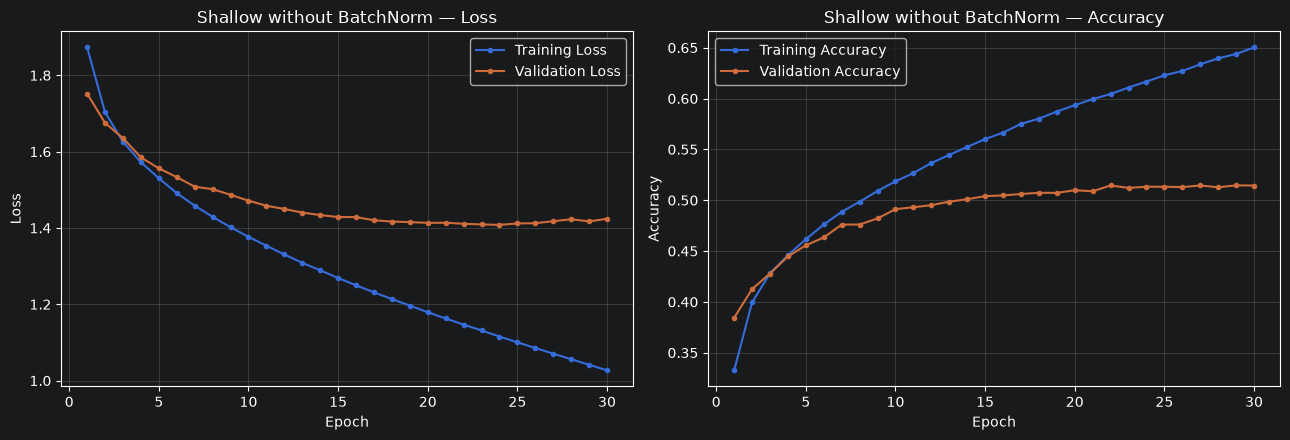

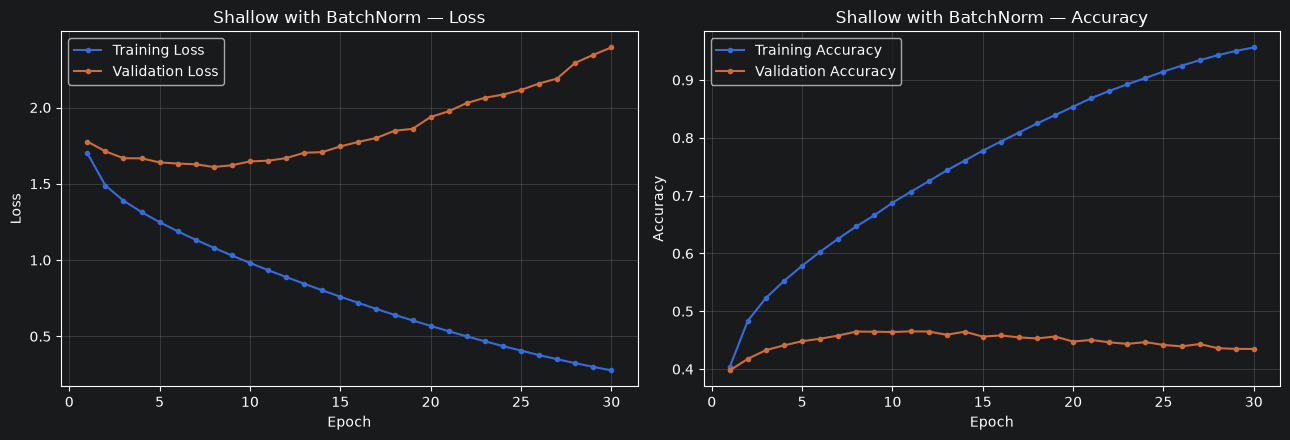

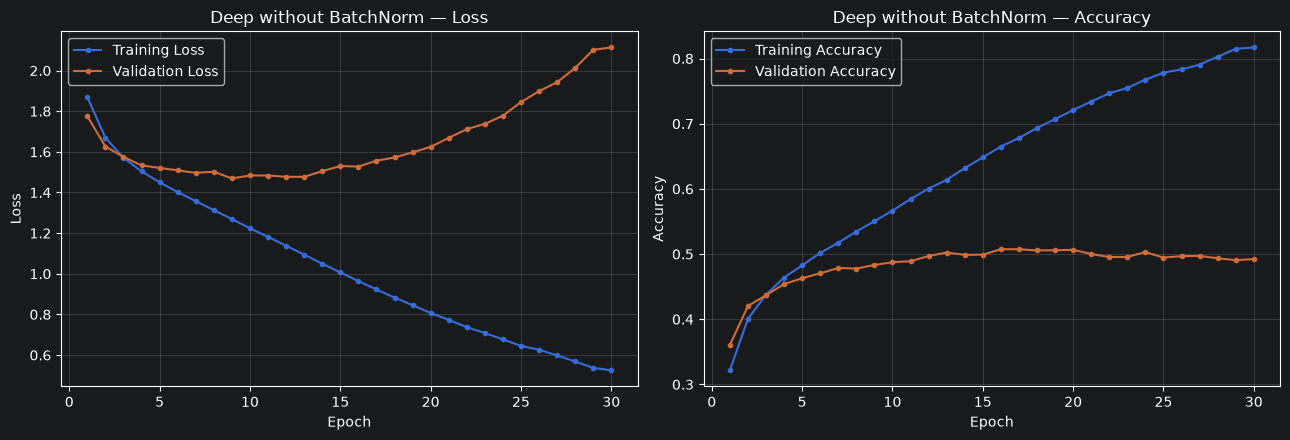

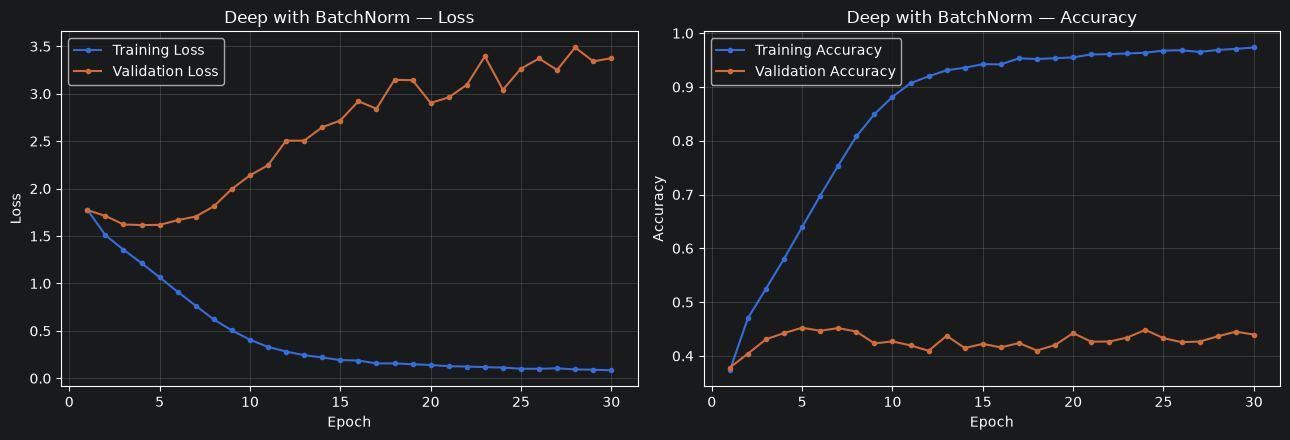

In [56]:
for bn_label in bn_histories:
    plot_curves(bn_histories[bn_label], bn_label)

In [57]:
def summarize_batchnorm(history, label):
    hist = history.history
    val_loss = np.array(hist['val_loss'])
    best = int(np.argmin(val_loss))
    reversals = int((np.diff(val_loss) > 0).sum())
    reached_45 = next((i + 1 for i, a in enumerate(hist['val_accuracy']) if a >= 0.45), None)
    return {
        'Model': label,
        'Best Epoch': best + 1,
        'Epochs to 45% Val Acc.': reached_45 if reached_45 is not None else 'never',
        'Train Acc.': round(hist['accuracy'][best], 4),
        'Val Acc.': round(hist['val_accuracy'][best], 4),
        'Val Loss': round(float(val_loss[best]), 4),
        'Generalization Gap': round(hist['accuracy'][best] - hist['val_accuracy'][best], 4),
        'Val Loss Reversals': f"{reversals}/{len(val_loss) - 1}",
    }

batchnorm_df = pd.DataFrame([summarize_batchnorm(bn_histories[l], l) for l in bn_histories])
batchnorm_df

,Model,Best Epoch,Epochs to 45% Val Acc.,Train Acc.,Val Acc.,Val Loss,Generalization Gap,Val Loss Reversals
0,Shallow without BatchNorm,24,5,0.6167,0.5133,1.4081,0.1034,6/29
1,Shallow with BatchNorm,8,6,0.6468,0.4649,1.6098,0.1820,22/29
2,Deep without BatchNorm,9,4,0.5504,0.4832,1.4690,0.0672,18/29
3,Deep with BatchNorm,4,5,0.5807,0.4425,1.6154,0.1382,20/29


### Batch Normalization Questions

**Did training become more stable?**
No — markedly less stable. On the selected architecture, validation loss moved in the wrong direction in 22 of 29 epoch transitions with Batch Normalization, against 6 of 29 without it.

**Did the model converge faster?**
It reaches its best epoch far sooner (epoch 8 against epoch 24), but to a worse result, and it is no quicker to reach 45% validation accuracy. What it accelerates is the fit to the training set, not progress toward a better model.

**Did Validation performance change?**
Yes, and it got worse on both architectures — roughly four percentage points lower, with validation loss rising in both cases.

**Was its effect more noticeable in the deeper network?**
No. The drop in validation accuracy, the rise in training accuracy and the widening of the generalization gap are all close to identical at both depths. The only asymmetry is stability: Batch Normalization destabilized the shallow model far more than the deep one, because the deep model was already unstable without it.

One limitation should be recorded. Batch Normalization was tested at the Learning Rate selected in Part 9, which was tuned on a network without it. Because normalizing the activations changes the effective step size, this experiment shows that Batch Normalization does not help at these settings rather than that it cannot help at any.

---
# Part 14 — Ablation Experiment

An ablation isolates a single modeling decision by removing it and changing nothing else. Part 12 tested each technique on its own; this tests whether **Dropout** still earns its place once the other selected settings are combined, which is a different question — a component can help in isolation and add nothing on top of the rest.

Model A is the full final configuration. Model B is identical except that Dropout is removed.

In [58]:
FINAL_DROPOUT = 0.2
FINAL_L2 = None
FINAL_EPOCHS = 30

# BatchNormalization is included only if Part 13 showed it lowered validation loss
# on the selected architecture, rather than because it is a common default.
bn_with = batchnorm_df.loc[batchnorm_df['Model'] == 'Shallow with BatchNorm', 'Val Loss'].iloc[0]
bn_without = batchnorm_df.loc[batchnorm_df['Model'] == 'Shallow without BatchNorm', 'Val Loss'].iloc[0]
FINAL_BN = bool(bn_with < bn_without)
print(f"BatchNorm val loss: with={bn_with:.4f} without={bn_without:.4f} -> included: {FINAL_BN}")

def build_final(dropout=FINAL_DROPOUT, l2=FINAL_L2, batchnorm=FINAL_BN):
    keras.utils.set_random_seed(SEED)
    kernel_reg = keras.regularizers.l2(l2) if l2 else None

    stack = [layers.Input(shape=(3072,)), layers.Dense(512, kernel_regularizer=kernel_reg, name='hidden_1')]
    if batchnorm:
        stack.append(layers.BatchNormalization(name='batchnorm_1'))
    stack.append(layers.Activation('relu', name='relu_1'))
    if dropout:
        stack.append(layers.Dropout(dropout, name='dropout'))
    stack.append(layers.Dense(10, activation='softmax', kernel_regularizer=kernel_reg, name='output'))

    model = keras.Sequential(stack, name='final_model')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=BEST_LEARNING_RATE),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def final_early_stopping():
    return keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                         restore_best_weights=True)

ablation_histories = {}

BatchNorm val loss: with=1.6098 without=1.4081 -> included: False


In [59]:
print("Model A - with Dropout")
ablation_model_a = build_final()
ablation_histories['A - with Dropout'] = ablation_model_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[final_early_stopping()],
    verbose=2
)

Model A - with Dropout
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3159 - loss: 1.9101 - val_accuracy: 0.3750 - val_loss: 1.7663
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3808 - loss: 1.7471 - val_accuracy: 0.4124 - val_loss: 1.6804
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4056 - loss: 1.6781 - val_accuracy: 0.4345 - val_loss: 1.6219
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4284 - loss: 1.6265 - val_accuracy: 0.4473 - val_loss: 1.5881
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4416 - loss: 1.5901 - val_accuracy: 0.4591 - val_loss: 1.5587
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4492 - loss: 1.5572 - val_accuracy: 0.4646 - val_loss: 1.5409
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4631 - loss: 1.5301 - val_accuracy: 0.4702 - val_loss: 1.5192
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4740 - loss: 1.5023 - val_accuracy: 0.4739 - val_loss: 1.5010
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4816 - loss: 1.4793 - 

In [60]:
print("Model B - without Dropout")
ablation_model_b = build_final(dropout=None)
ablation_histories['B - without Dropout'] = ablation_model_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[final_early_stopping()],
    verbose=2
)

Model B - without Dropout
Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3327 - loss: 1.8729 - val_accuracy: 0.3844 - val_loss: 1.7520
Epoch 2/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3995 - loss: 1.7028 - val_accuracy: 0.4126 - val_loss: 1.6751
Epoch 3/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4281 - loss: 1.6256 - val_accuracy: 0.4279 - val_loss: 1.6353
Epoch 4/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4459 - loss: 1.5721 - val_accuracy: 0.4447 - val_loss: 1.5849
Epoch 5/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4616 - loss: 1.5301 - val_accuracy: 0.4556 - val_loss: 1.5563
Epoch 6/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4761 - loss: 1.4913 - val_accuracy: 0.4634 - val_loss: 1.5331
Epoch 7/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4886 - loss: 1.4584 - val_accuracy: 0.4760 - val_loss: 1.5081
Epoch 8/30
1250/1250 - 5s - 4ms/step - accuracy: 0.4985 - loss: 1.4291 - val_accuracy: 0.4761 - val_loss: 1.5016
Epoch 9/30
1250/1250 - 5s - 4ms/step - accuracy: 0.5091 - loss: 1.4018

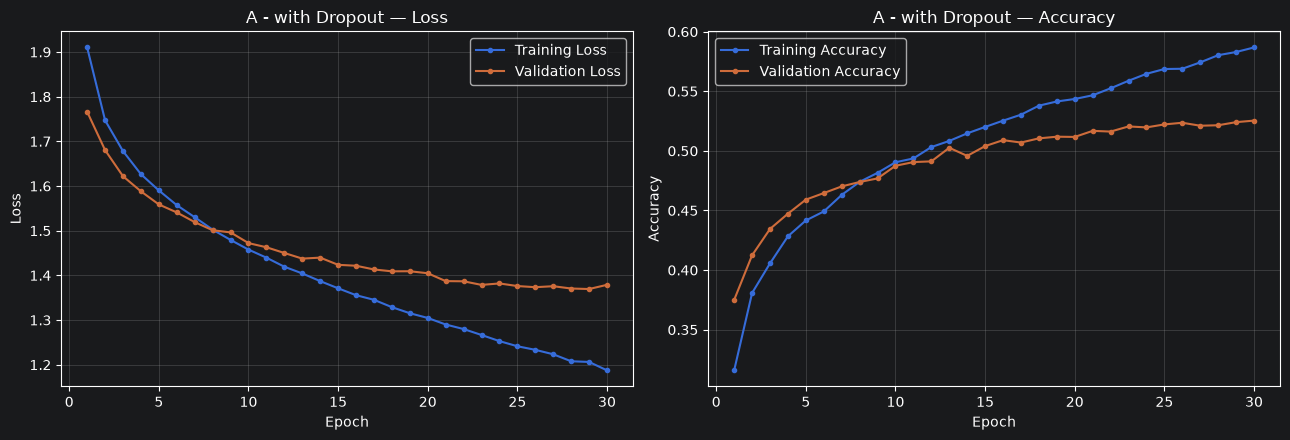

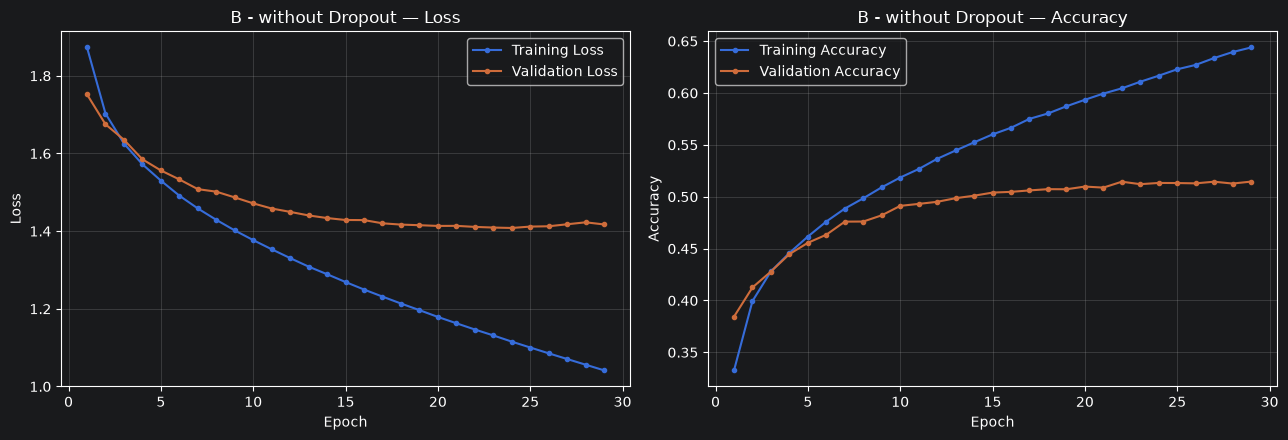

,Experiment,Epochs Run,Best Epoch,Train Acc.,Val Acc.,Val Loss,Generalization Gap,Final Train Acc.,Final Val Acc.
0,A - with Dropout,30,29,0.5829,0.5241,1.3694,0.0588,0.5867,0.5254
1,B - without Dropout,29,24,0.6167,0.5133,1.4081,0.1034,0.6439,0.5146


In [61]:
for ab_label in ablation_histories:
    plot_curves(ablation_histories[ab_label], ab_label)

ablation_df = pd.DataFrame([summarize_regularization(ablation_histories[l], l)
                            for l in ablation_histories])
ablation_df

### Ablation Question

**Did Dropout actually contribute to better performance or generalization?**

Yes. Removing it lowers validation accuracy, raises validation loss, and nearly doubles the generalization gap (0.1034 against 0.0588). Training accuracy moves in the opposite direction, rising once Dropout is removed — which is precisely the trade the technique is meant to make.

The validation accuracy margin on its own is about one percentage point and would be weak evidence. The gap and the validation loss are what make the result convincing, and they point the same way.

---
# Part 15 — Final Model

The final model combines only the settings that the experiments justified. Each choice below points to the part that produced the evidence for it, and any technique that did not demonstrably help was left out rather than included by default.

In [62]:
final_model = build_final()
final_model.summary()

final_trainable = int(np.sum([np.prod(v.shape) for v in final_model.trainable_weights]))
print("\nFinal trainable parameters:", f"{final_trainable:,}")

Model: "final_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,578,506 (6.02 MB)

 Trainable params: 1,578,506 (6.02 MB)

 Non-trainable params: 0 (0.00 B)


Final trainable parameters: 1,578,506


Epoch 1/30
1250/1250 - 5s - 4ms/step - accuracy: 0.3159 - loss: 1.9101 - val_accuracy: 0.3750 - val_loss: 1.7663
Epoch 2/30
1250/1250 - 4s - 3ms/step - accuracy: 0.3808 - loss: 1.7471 - val_accuracy: 0.4124 - val_loss: 1.6804
Epoch 3/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4056 - loss: 1.6781 - val_accuracy: 0.4345 - val_loss: 1.6219
Epoch 4/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4284 - loss: 1.6265 - val_accuracy: 0.4473 - val_loss: 1.5881
Epoch 5/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4416 - loss: 1.5901 - val_accuracy: 0.4591 - val_loss: 1.5587
Epoch 6/30
1250/1250 - 4s - 4ms/step - accuracy: 0.4492 - loss: 1.5572 - val_accuracy: 0.4646 - val_loss: 1.5409
Epoch 7/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4631 - loss: 1.5301 - val_accuracy: 0.4702 - val_loss: 1.5192
Epoch 8/30
1250/1250 - 4s - 4ms/step - accuracy: 0.4740 - loss: 1.5023 - val_accuracy: 0.4739 - val_loss: 1.5010
Epoch 9/30
1250/1250 - 4s - 3ms/step - accuracy: 0.4816 - loss: 1.4793 - val_accuracy: 0.4769 - 

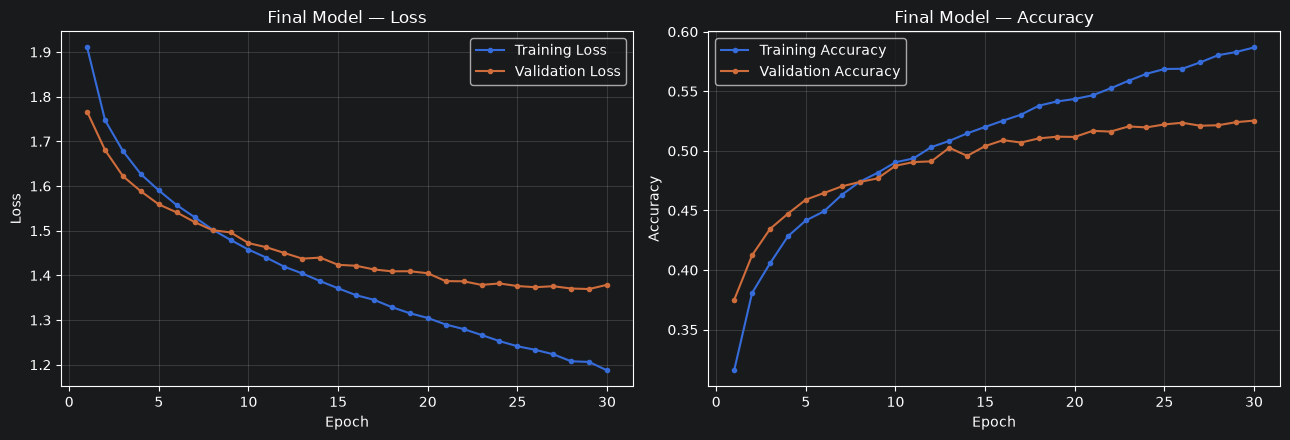

,Experiment,Epochs Run,Best Epoch,Train Acc.,Val Acc.,Val Loss,Generalization Gap,Final Train Acc.,Final Val Acc.
0,Final Model,30,29,0.5829,0.5241,1.3694,0.0588,0.5867,0.5254


In [63]:
history_final = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=FINAL_EPOCHS,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[final_early_stopping()],
    verbose=2
)

plot_curves(history_final, "Final Model")
pd.DataFrame([summarize_regularization(history_final, 'Final Model')])

### Final Model Justification

**Architecture.** Shallow — one hidden layer of 512 units, 1,578,506 trainable parameters. Selected in Part 7; the tuning that followed improved it by considerably more than the spread between the three architectures ever amounted to.

**Learning Rate.** `0.0001`, from Part 9. The four tested rates form a clear U-shape with the minimum here, and the value inherited from Parts 3-8 proved to be an order of magnitude too large.

**Batch Size.** `32`, from Part 10. The middle of the tested range beats both ends; `32` and `64` were close enough to be treated as equivalent.

**Optimizer.** Adam, from Part 11. Close to SGD at its own best rate, and retained partly because it adapts its step size per weight, which matters once regularization changes the loss surface.

**Regularization included.** Dropout `0.2` — the only technique in Part 12 to improve validation accuracy and validation loss together, and confirmed by the Part 14 ablation. Early Stopping on validation loss with `restore_best_weights`, which returns the best epoch rather than the last.

**Techniques deliberately excluded, and why.** L2, because it raised validation loss above the unregularized baseline. Batch Normalization, because Part 13 showed it lowered validation accuracy on both architectures. Dropout `0.5`, because it pushed the model into underfitting — its training accuracy fell below its validation accuracy.

---
# Part 16 — Final Test Evaluation

The Test Set has been untouched since Part 2. It is used exactly once here, on the final model, and no tuning is performed after seeing the result.

In [64]:
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Test Loss:     1.3726
Test Accuracy: 0.5154

              precision    recall  f1-score   support

    airplane     0.5125    0.6560    0.5754      1000
  automobile     0.6830    0.5840    0.6296      1000
        bird     0.4363    0.3290    0.3751      1000
         cat     0.3512    0.3610    0.3560      1000
        deer     0.4795    0.4220    0.4489      1000
         dog     0.4085    0.4220    0.4152      1000
        frog     0.5764    0.5620    0.5691      1000
       horse     0.5553    0.6080    0.5804      1000
        ship     0.5492    0.7150    0.6212      1000
       truck     0.6203    0.4950    0.5506      1000

    accuracy                         0.5154     10000
   macro avg     0.5172    0.5154    0.5122     10000
weighted avg     0.5172    0.5154    0.5122     10000



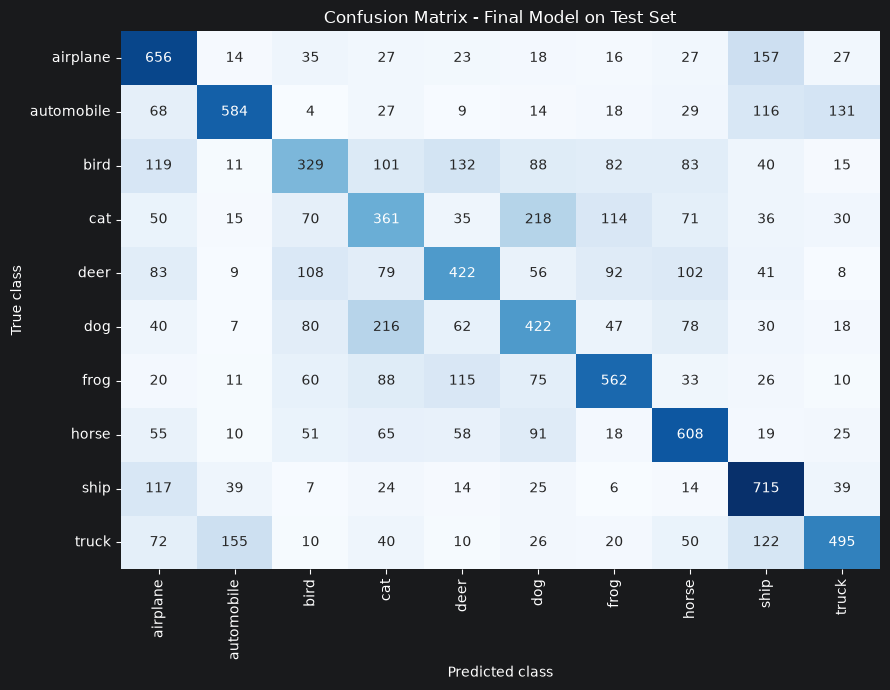

In [65]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, cbar=False)
plt.title("Confusion Matrix - Final Model on Test Set")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()

### Test Evaluation

**Test performance against validation performance.** Test accuracy is 0.5154 against a validation accuracy of 0.5241 — a drop of under one percentage point. After more than twenty experiments selected against the validation set, that small gap indicates the validation estimate had not become optimistic, and the test set gives an honest reading.

**Which classes the per-class scores show as strong or weak.** Rigid, man-made objects score highest — automobile, ship and airplane all reach F1 scores above 0.57. Deformable animals score lowest, with cat at 0.356 and bird at 0.375. The precision and recall figures also show the model over-predicting ship and airplane and under-predicting truck, which is consistent with it relying on broad colour cues rather than object shape.

---
# Part 17 — Error Analysis

A single accuracy figure says nothing about *where* the model fails. This section identifies which classes are handled well, which are not, which pairs are confused with each other, and what the failures look like.

In [66]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

class_accuracy_df = pd.DataFrame({
    'Class': class_names,
    'Correct': cm.diagonal(),
    'Total': cm.sum(axis=1),
    'Accuracy': np.round(per_class_accuracy, 4),
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("Easiest classes")
print(class_accuracy_df.head(3).to_string(index=False))
print("\nHardest classes")
print(class_accuracy_df.tail(3).to_string(index=False))
class_accuracy_df

Easiest classes
   Class  Correct  Total  Accuracy
    ship      715   1000     0.715
airplane      656   1000     0.656
   horse      608   1000     0.608

Hardest classes
Class  Correct  Total  Accuracy
  dog      422   1000     0.422
  cat      361   1000     0.361
 bird      329   1000     0.329


,Class,Correct,Total,Accuracy
0,ship,715,1000,0.715
1,airplane,656,1000,0.656
2,horse,608,1000,0.608
3,automobile,584,1000,0.584
4,frog,562,1000,0.562
5,truck,495,1000,0.495
6,deer,422,1000,0.422
7,dog,422,1000,0.422
8,cat,361,1000,0.361
9,bird,329,1000,0.329


In [67]:
confusions = []
for true_idx in range(10):
    for pred_idx in range(10):
        if true_idx != pred_idx:
            confusions.append({
                'True Class': class_names[true_idx],
                'Predicted As': class_names[pred_idx],
                'Count': int(cm[true_idx, pred_idx]),
            })

confusion_pairs_df = (pd.DataFrame(confusions)
                      .sort_values('Count', ascending=False)
                      .head(10)
                      .reset_index(drop=True))
print("Most frequently confused pairs")
confusion_pairs_df

Most frequently confused pairs


,True Class,Predicted As,Count
0,cat,dog,218
1,dog,cat,216
2,airplane,ship,157
3,truck,automobile,155
4,bird,deer,132
5,automobile,truck,131
6,truck,ship,122
7,bird,airplane,119
8,ship,airplane,117
9,automobile,ship,116


Misclassified test images: 4846 of 10000


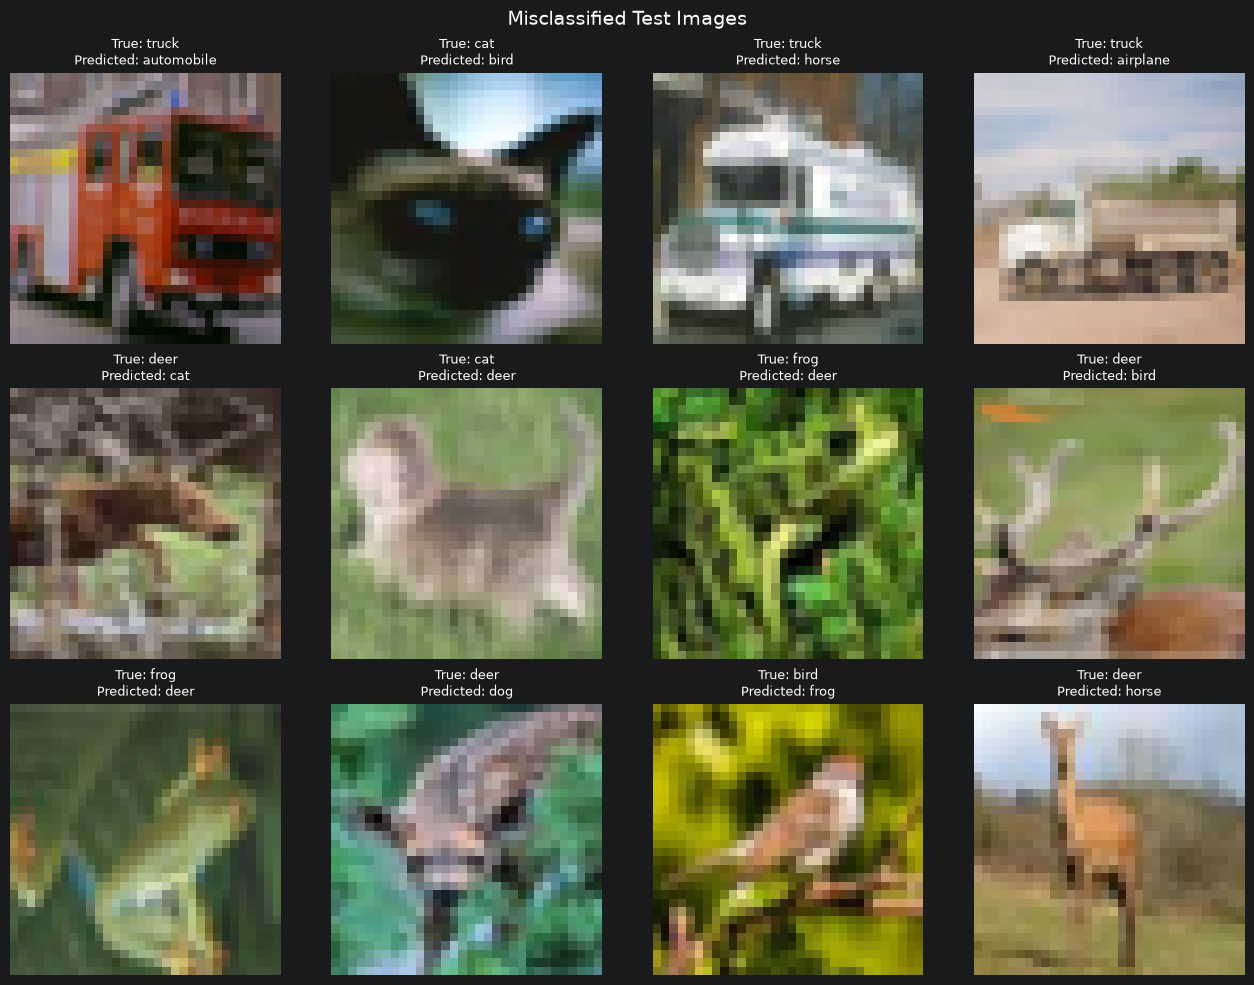

In [68]:
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Misclassified test images: {len(wrong_idx)} of {len(y_test)}")

rng = np.random.default_rng(SEED)
sample_wrong = rng.choice(wrong_idx, size=12, replace=False)

plt.figure(figsize=(13, 10))
for i, idx in enumerate(sample_wrong):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test_raw[idx])
    plt.title(f"True: {class_names[y_test[idx]]}\nPredicted: {class_names[y_pred[idx]]}",
              fontsize=9)
    plt.axis('off')

plt.suptitle("Misclassified Test Images", fontsize=14)
plt.tight_layout()
plt.show()

### Error Analysis Questions

**What patterns do you notice in the errors?**
The errors are highly concentrated. The ten most frequent confusions account for just under a third of all mistakes — 1,483 of 4,846 — out of ninety possible off-diagonal pairs. Nine of those ten are confusions *within* a category, an animal mistaken for another animal or a vehicle for another vehicle. The one exception, bird predicted as airplane, makes the same point differently: both are small objects on a large field of sky. Accuracy also splits cleanly along rigidity: the best classes are ship, airplane and horse, and the worst are bird, cat and dog.

**Are specific classes frequently confused?**
Yes, and symmetrically. Cat and dog are by far the largest pair, misclassified as each other in both directions in similar numbers. Airplane and ship form the second cluster, along with truck and automobile, and bird is spread across deer and airplane.

**Why might those classes be difficult for a Dense Neural Network?**
Because the model never sees shape. Flattening turns each image into 3072 independent values, so the network can only learn how much each individual pixel position matters — it has no way to represent that some pixels form an ear or a wing. What survives that representation is broad colour and brightness statistics, which is why airplane and ship are confused so heavily: both sit on large, uniform blue backgrounds, and the background is the strongest signal left.

It also explains the split between rigid and deformable classes. A ship occupies a similar region of the frame in most photographs, so per-position weights transfer between examples. A cat may be curled, standing or turned, placing entirely different values in the same input slots, and with no translation invariance the network must learn each pose and position separately.

---
# Part 18 — Experiment Tracking

A single table summarizing every major experiment in the project, so the effect of each decision can be compared in one place.

In [69]:
def best_val(history):
    return round(max(history.history['val_accuracy']), 4)

def lookup(store, key):
    if key not in store:
        print(f"WARNING: {key!r} was not found - its experiment cell has not been run")
        return float('nan')
    return best_val(store[key])

tracking_rows = [
    ('Baseline',            '1 x 256',  0.0010, 128, 'Adam', '-',   'No',  'No',  best_val(history_baseline)),
    ('Shallow',             '1 x 512',  0.0010, 128, 'Adam', '-',   'No',  'No',  best_val(history_shallow)),
    ('Medium',              '3 layers', 0.0010, 128, 'Adam', '-',   'No',  'No',  best_val(history_medium)),
    ('Deep',                '5 layers', 0.0010, 128, 'Adam', '-',   'No',  'No',  best_val(history_deep)),
    ('LR Tuning (best)',    '1 x 512',  0.0001, 128, 'Adam', '-',   'No',  'No',  lookup(lr_histories, 0.0001)),
    ('Batch Tuning (best)', '1 x 512',  0.0001,  32, 'Adam', '-',   'No',  'No',  lookup(batch_histories, 32)),
    ('Optimizer - SGD',     '1 x 512',  0.0100,  32, 'SGD',  '-',   'No',  'No',  lookup(optimizer_histories, 'SGD (lr=0.01)')),
    ('Dropout 0.2',         '1 x 512',  0.0001,  32, 'Adam', '0.2', 'No',  'No',  lookup(reg_histories, 'B - Dropout 0.2')),
    ('L2 1e-4',             '1 x 512',  0.0001,  32, 'Adam', '-',   'No',  'No',  lookup(reg_histories, 'D - L2 1e-4')),
    ('BatchNorm',           '1 x 512',  0.0001,  32, 'Adam', '-',   'Yes', 'No',  lookup(bn_histories, 'Shallow with BatchNorm')),
    ('Final Model',         '1 x 512',  0.0001,  32, 'Adam',
     str(FINAL_DROPOUT) if FINAL_DROPOUT else '-', 'Yes' if FINAL_BN else 'No', 'Yes',
     best_val(history_final)),
]

tracking_df = pd.DataFrame(tracking_rows, columns=[
    'Experiment', 'Architecture', 'LR', 'Batch', 'Optimizer',
    'Dropout', 'BatchNorm', 'Early Stop', 'Best Val Acc.'])
tracking_df

,Experiment,Architecture,LR,Batch,Optimizer,Dropout,BatchNorm,Early Stop,Best Val Acc.
0,Baseline,1 x 256,0.0010,128,Adam,-,No,No,0.4835
1,Shallow,1 x 512,0.0010,128,Adam,-,No,No,0.4835
2,Medium,3 layers,0.0010,128,Adam,-,No,No,0.4954
3,Deep,5 layers,0.0010,128,Adam,-,No,No,0.4965
4,LR Tuning (best),1 x 512,0.0001,128,Adam,-,No,No,0.4947
5,Batch Tuning (best),1 x 512,0.0001,32,Adam,-,No,No,0.5098
6,Optimizer - SGD,1 x 512,0.0100,32,SGD,-,No,No,0.5004
7,Dropout 0.2,1 x 512,0.0001,32,Adam,0.2,No,No,0.5254
8,L2 1e-4,1 x 512,0.0001,32,Adam,-,No,No,0.5198
9,BatchNorm,1 x 512,0.0001,32,Adam,-,Yes,No,0.4652


---
# Part 19 — Final Conclusion

**What happened when network depth increased?**
Training accuracy rose with every added layer, but validation performance did not follow, and the generalization gap widened from roughly 0.04 to 0.11. Depth bought capacity to fit the training set rather than the ability to generalize.

**Did the Deep Network outperform the Shallow Network?**
Not meaningfully. The three architectures finished within about a point of each other on validation accuracy — a margin small enough that it should not be treated as a decisive result — while the deep model carried more than twice the parameters and roughly two and a half times the generalization gap. The shallow architecture was carried forward, and the tuning that followed improved it by far more than the spread between architectures was ever worth.

**What was the main problem identified from the Learning Curves?**
Initially that the selected model had not converged: both curves were still improving when training stopped. Once it was trained long enough to reach its ceiling, the problem changed to overfitting, with the unregularized model's gap reaching 0.10.

**Which Hyperparameter had the greatest effect on training?**
The Learning Rate, decisively. At `0.01` the model never fit even the training set, reaching 0.29 validation accuracy; at `0.0001` it reached 0.49. That swing is larger than every other decision in the project put together.

**Which Regularization technique was most useful?**
Dropout at 0.2 — the only one to improve validation accuracy and validation loss at the same time while nearly halving the generalization gap, and the Part 14 ablation confirmed it still earns its place inside the combined model.

**Did the model with the highest Training Accuracy also generalize best?**
No, and the project contradicts it three separate times. The deep network had the highest training accuracy in Part 7 and the widest gap. The unregularized run had the highest training accuracy in Part 12 and lost to Dropout. Batch Normalization raised training accuracy on both architectures in Part 13 while lowering validation accuracy on both.

**What final architecture and configuration did you select?**
One hidden layer of 512 units with ReLU and a Softmax output — 1,578,506 trainable parameters — trained with Adam at `0.0001`, batch size 32, Dropout 0.2 and Early Stopping on validation loss with `restore_best_weights`. No L2 and no Batch Normalization.

**What evidence supports your decision?**
Every element traces to a controlled experiment: the Learning Rate to Part 9's four-rate sweep, the batch size to Part 10, the optimizer to Part 11, Dropout to Part 12 and then to the Part 14 ablation, and both exclusions to the experiments that rejected them. The final test accuracy of 0.5154 sits within one point of the validation accuracy it was selected on, which suggests the selection process did not overfit the validation set.

**What limitations still remain in your final model?**
The ceiling is the main one: 51.5% on the test set, which is close to what a fully connected network can achieve on this data. Several decisions were separated by around a percentage point — batch 32 against 64, and Adam against SGD — which is the scale a single run can vary by, so those were reported as ties rather than as findings. Layer width beyond 512, learning-rate schedules and data augmentation were never tested, and Batch Normalization was only tested at a Learning Rate tuned without it. The hardest classes remain poor, with bird at 0.33 and cat at 0.36.

---
# Part 20 — Reflection: Preparing for Computer Vision

**What are the limitations of using a fully connected Dense Neural Network for image data?**
It treats an image as an unordered list of numbers. There is no notion of adjacency, no translation invariance and no weight sharing, and the parameter cost scales directly with input size — 99.6% of this model's parameters sit in the single layer facing the raw pixels.

**What happens to the spatial structure of the image after flattening?**
It is discarded entirely. Two pixels that sit side by side become positions 0 and 3 in a list, and a pixel directly below becomes position 96. Nothing in the representation records that any of them were related.

**Does the Dense Network explicitly understand which pixels are next to each other?**
No. Each weight connects one input position to one neuron, and the neuron sums all 3072 inputs with no term expressing relative position. Any spatial relationship it exploits has to be relearned independently for every location it might appear in.

**Why might this representation make image classification difficult?**
Because an object shifted by a few pixels becomes a completely different input vector, so each class must be learned separately at every position it can occupy. The error analysis shows the consequence: the most frequent confusions are all within-category, airplane and ship are confused largely because they share uniform blue backgrounds rather than any shape similarity, and the deformable classes fail worst while rigid ones succeed.

**What characteristics would an architecture designed specifically for images need to preserve?**
Locality, so that neighbouring pixels stay related; translation invariance, so a feature learned once is recognized anywhere in the frame; weight sharing, so one detector is reused across positions instead of relearned for each; and hierarchy, so simple edges can compose into parts and parts into objects. Those four properties are precisely what a convolutional layer provides.